In [1]:
import pickle
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
import tensorflow_probability.substrates.jax.bijectors as tfb

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

In [ ]:
# Define the filename
filename = "margarine_comp_results.pkl"

# Load the MCMC results and samples
with open(filename, 'rb') as f:
    loaded_data = pickle.load(f)

mcmc_results = loaded_data['mcmc_results']
posterior_samples = loaded_data['posterior_samples']
print(f"Successfully loaded data from {filename}")

# Infer dimensions directly from the posterior samples shape
# mu_k shape: (n_chains, n_draws, K, P)
# Delta shape: (n_chains, n_draws, D, P)
K = posterior_samples["mu_k"].shape[2]
P = posterior_samples["mu_k"].shape[3]
D = posterior_samples["Delta"].shape[2]

print(f"Inferred Dimensions - Components (K): {K}, Parameters (P): {P}, Demographics (D): {D}")

# Define metadata for labeling
param_names = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "log(price)"]
demo_names = ["log(Income)", "Family size"]

Successfully loaded data from margarine_5comp_results.pkl
Inferred Dimensions - Components (K): 5, Parameters (P): 6, Demographics (D): 2


Plotting Cholesky Traces...


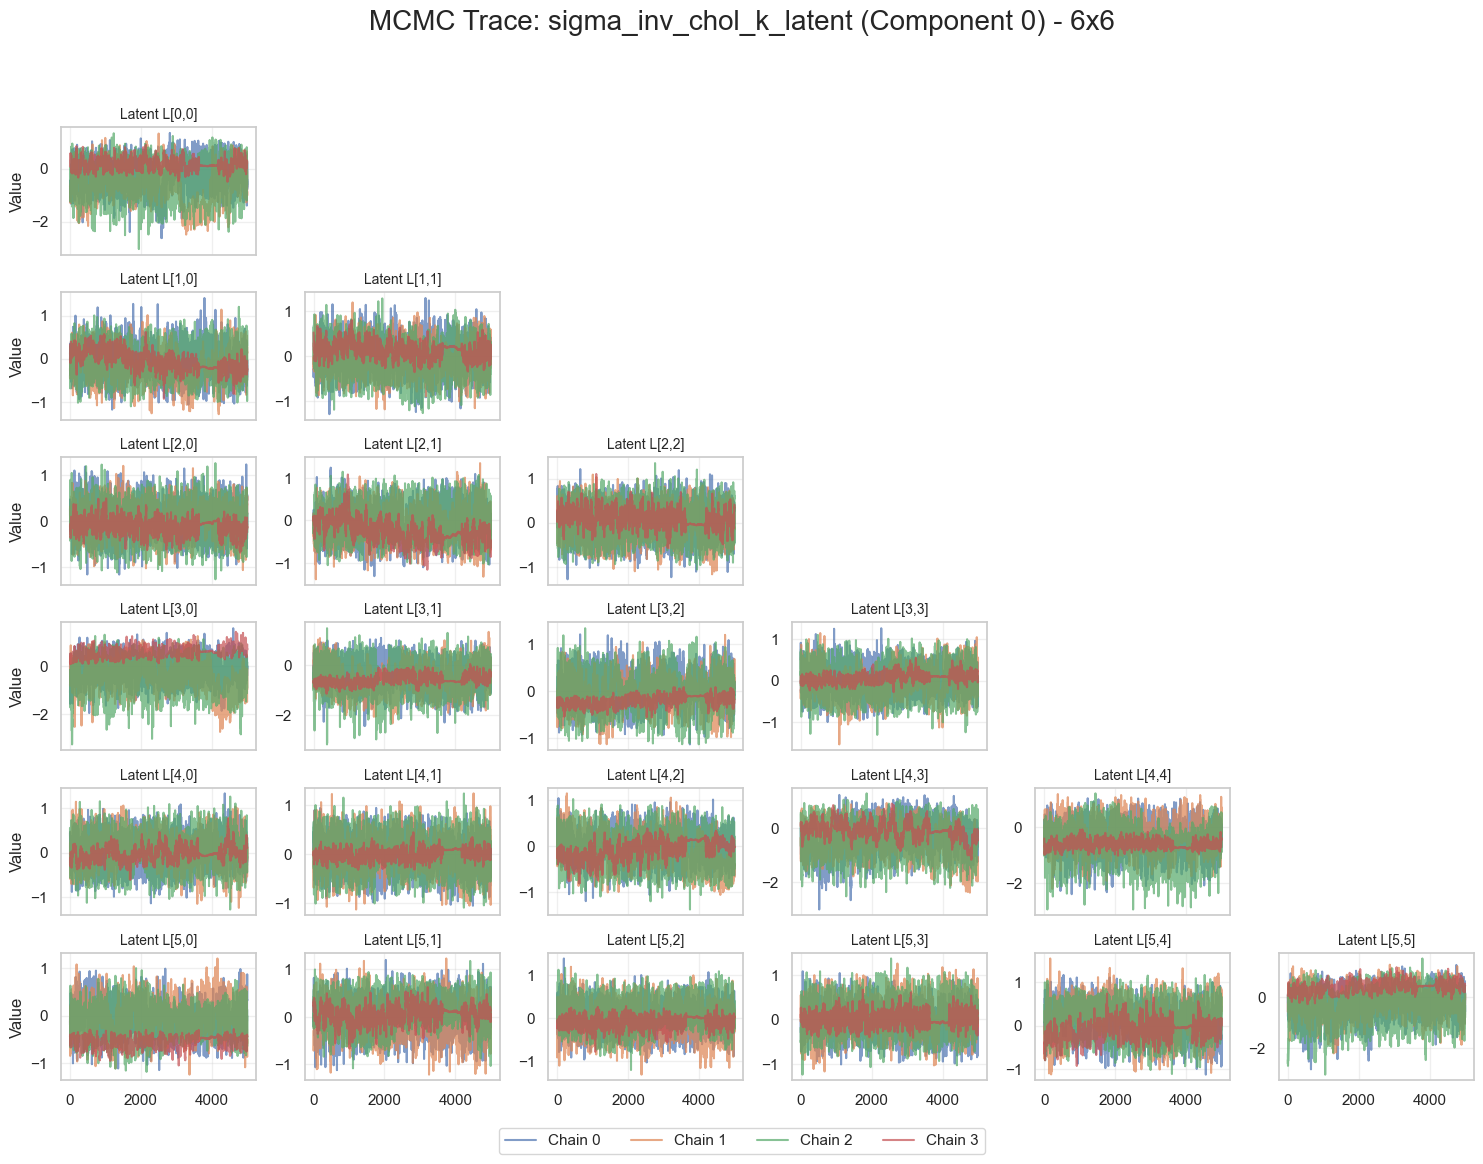

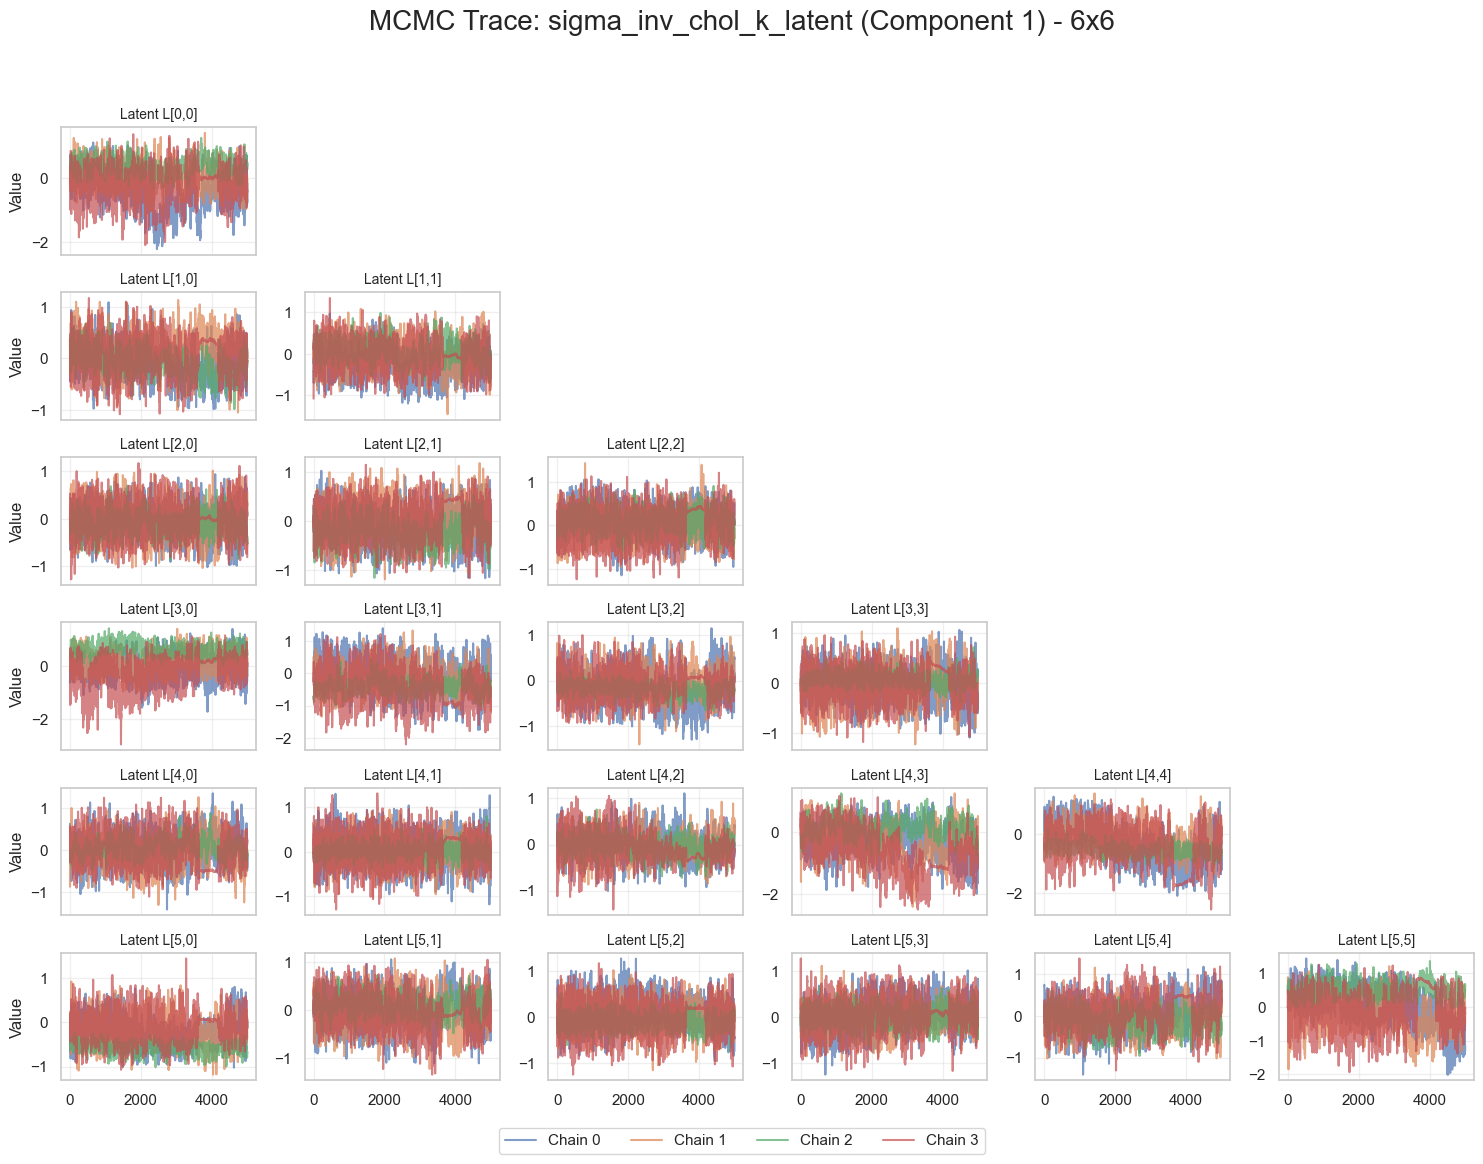

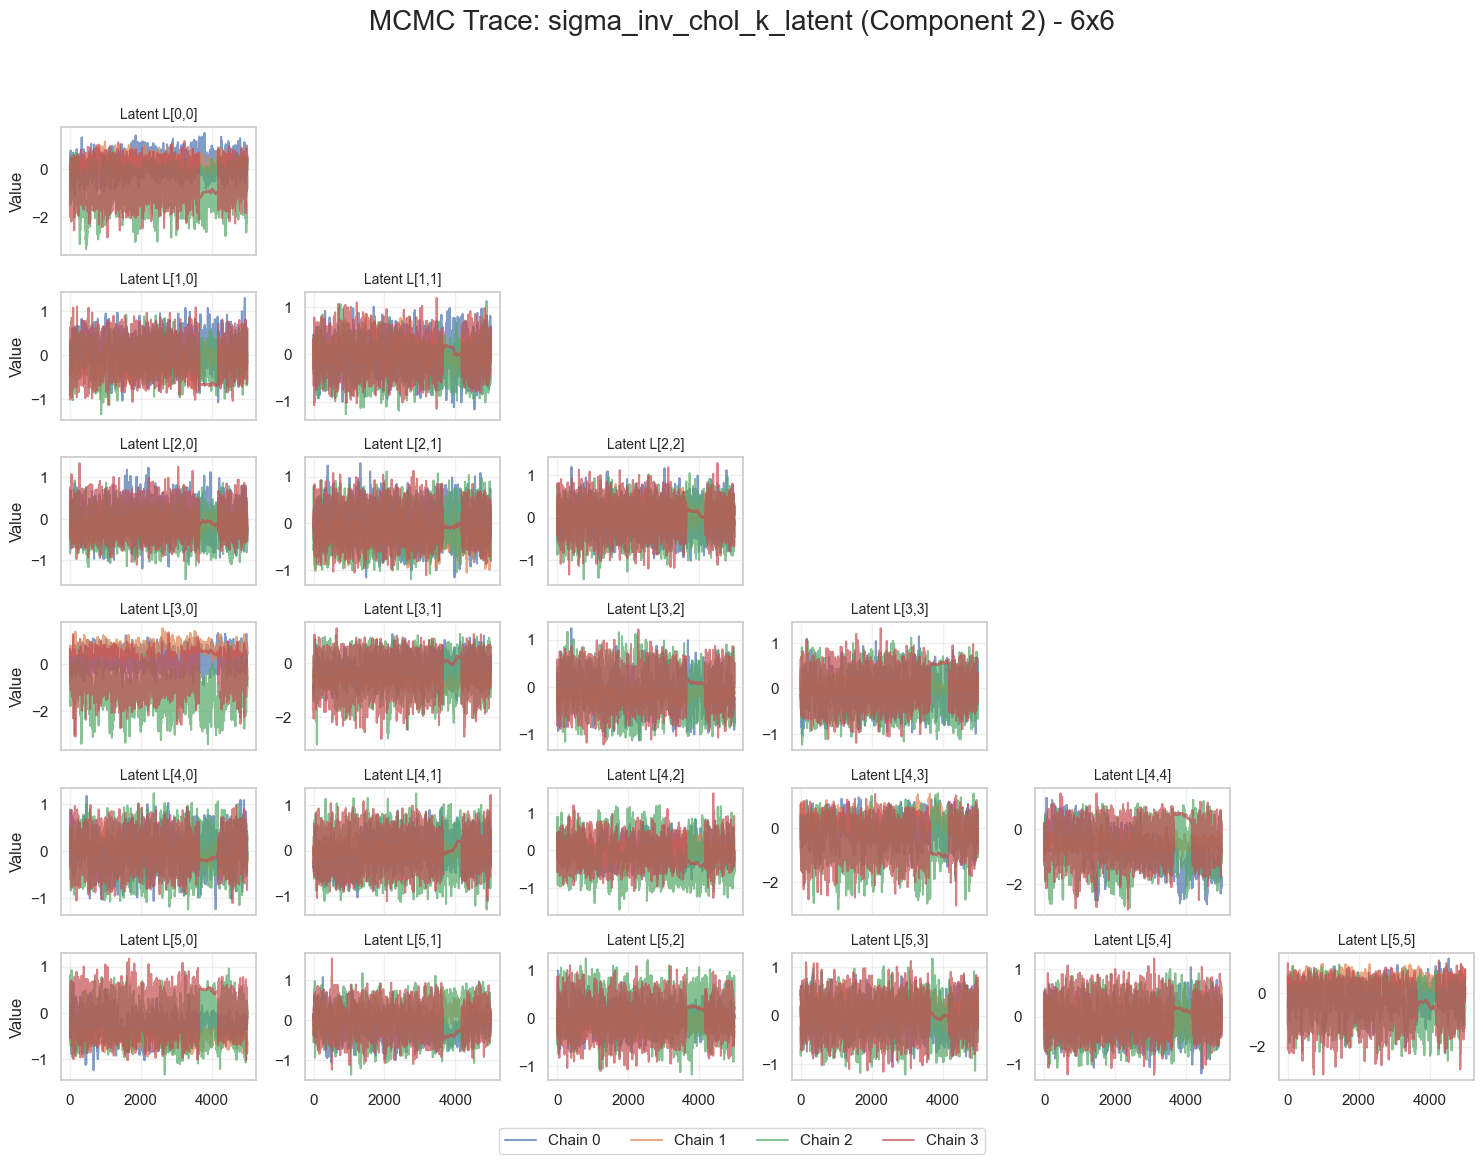

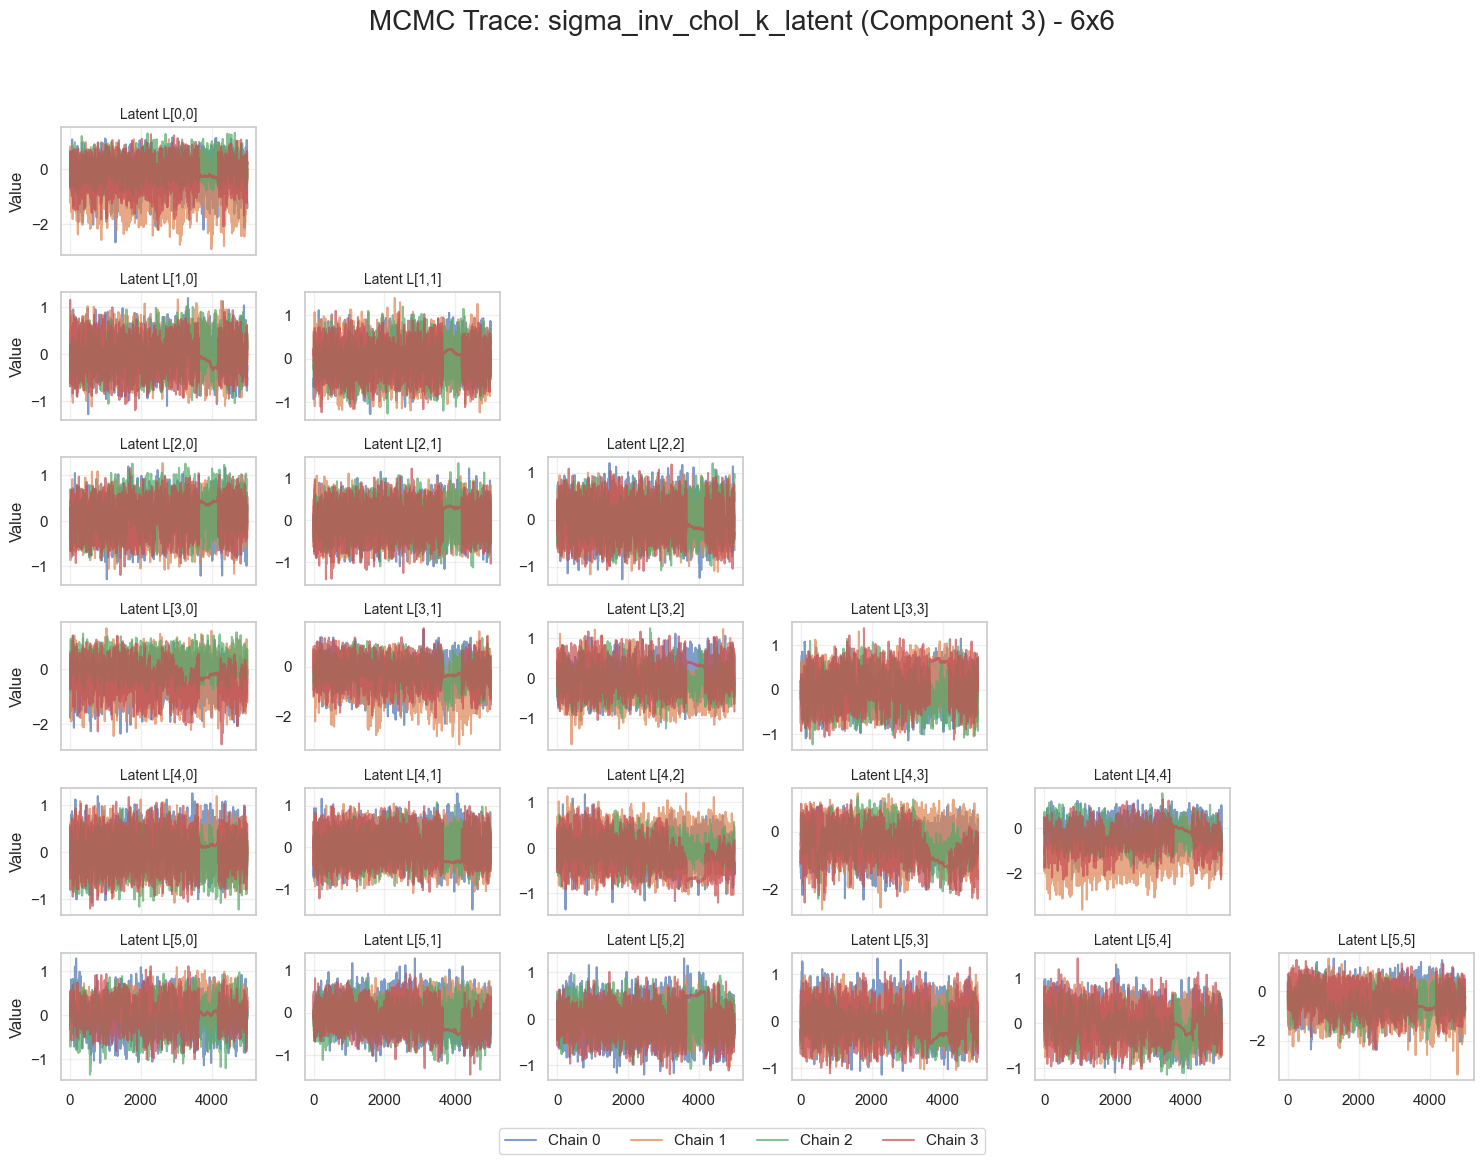

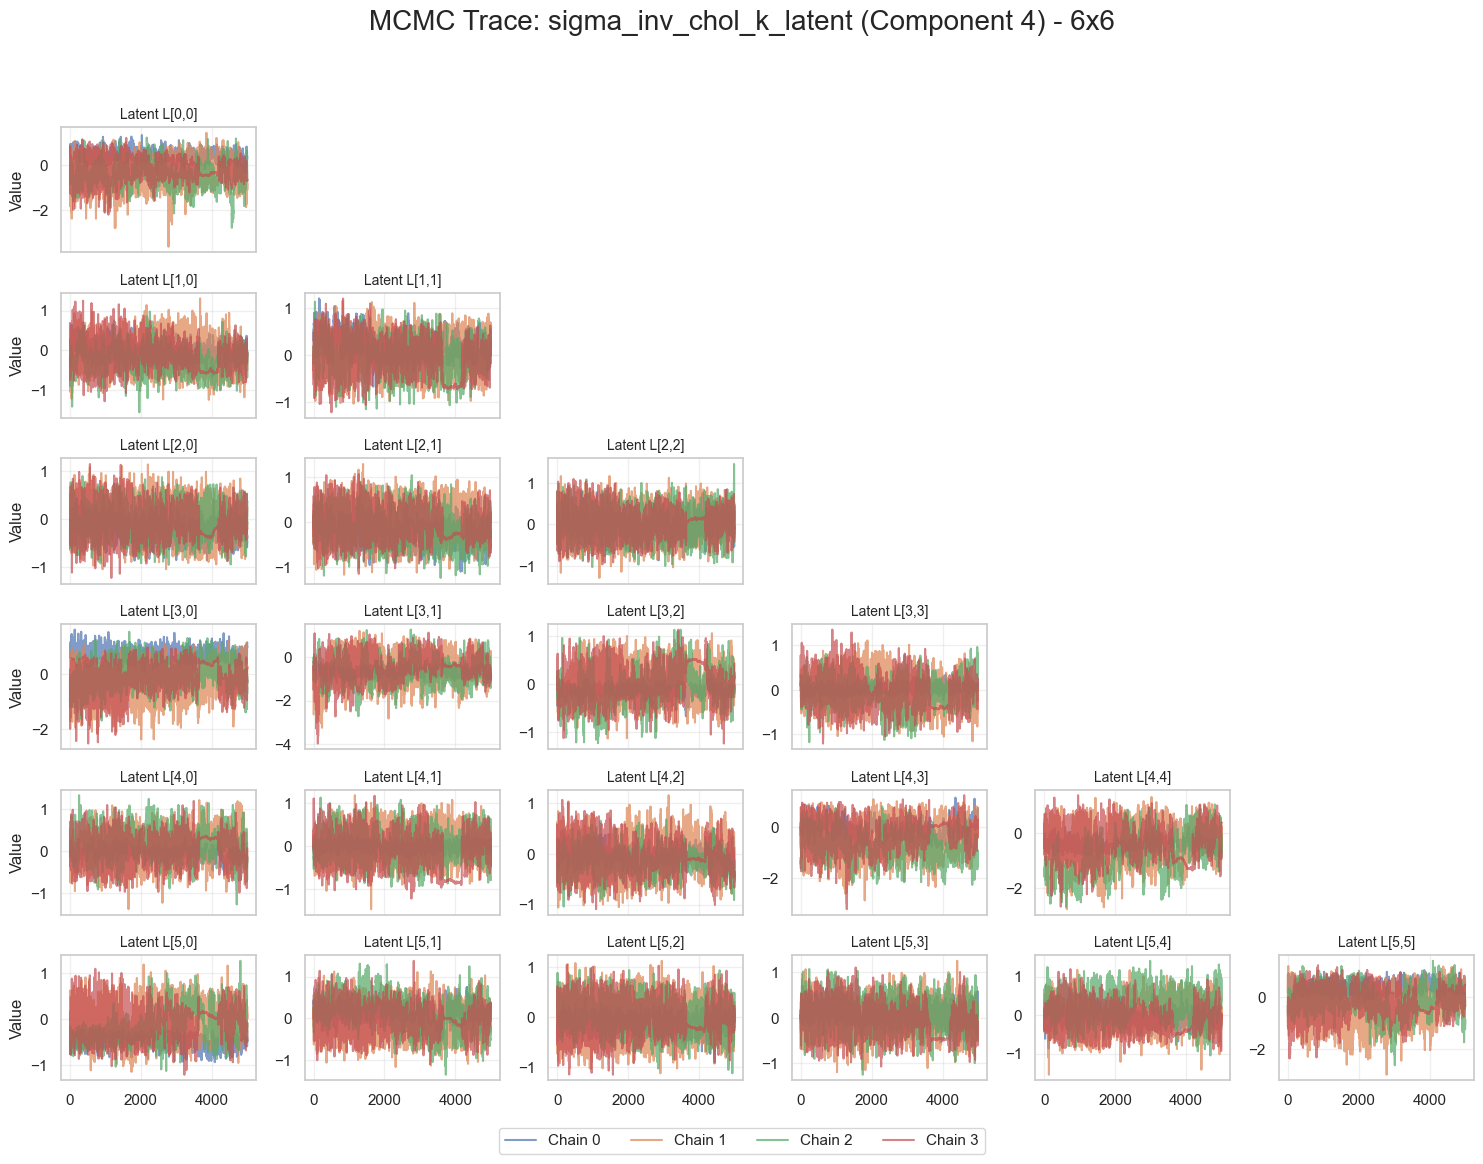


Recovering Covariance Matrices (Sigma_k) from samples...

Plotting Posterior Covariances...


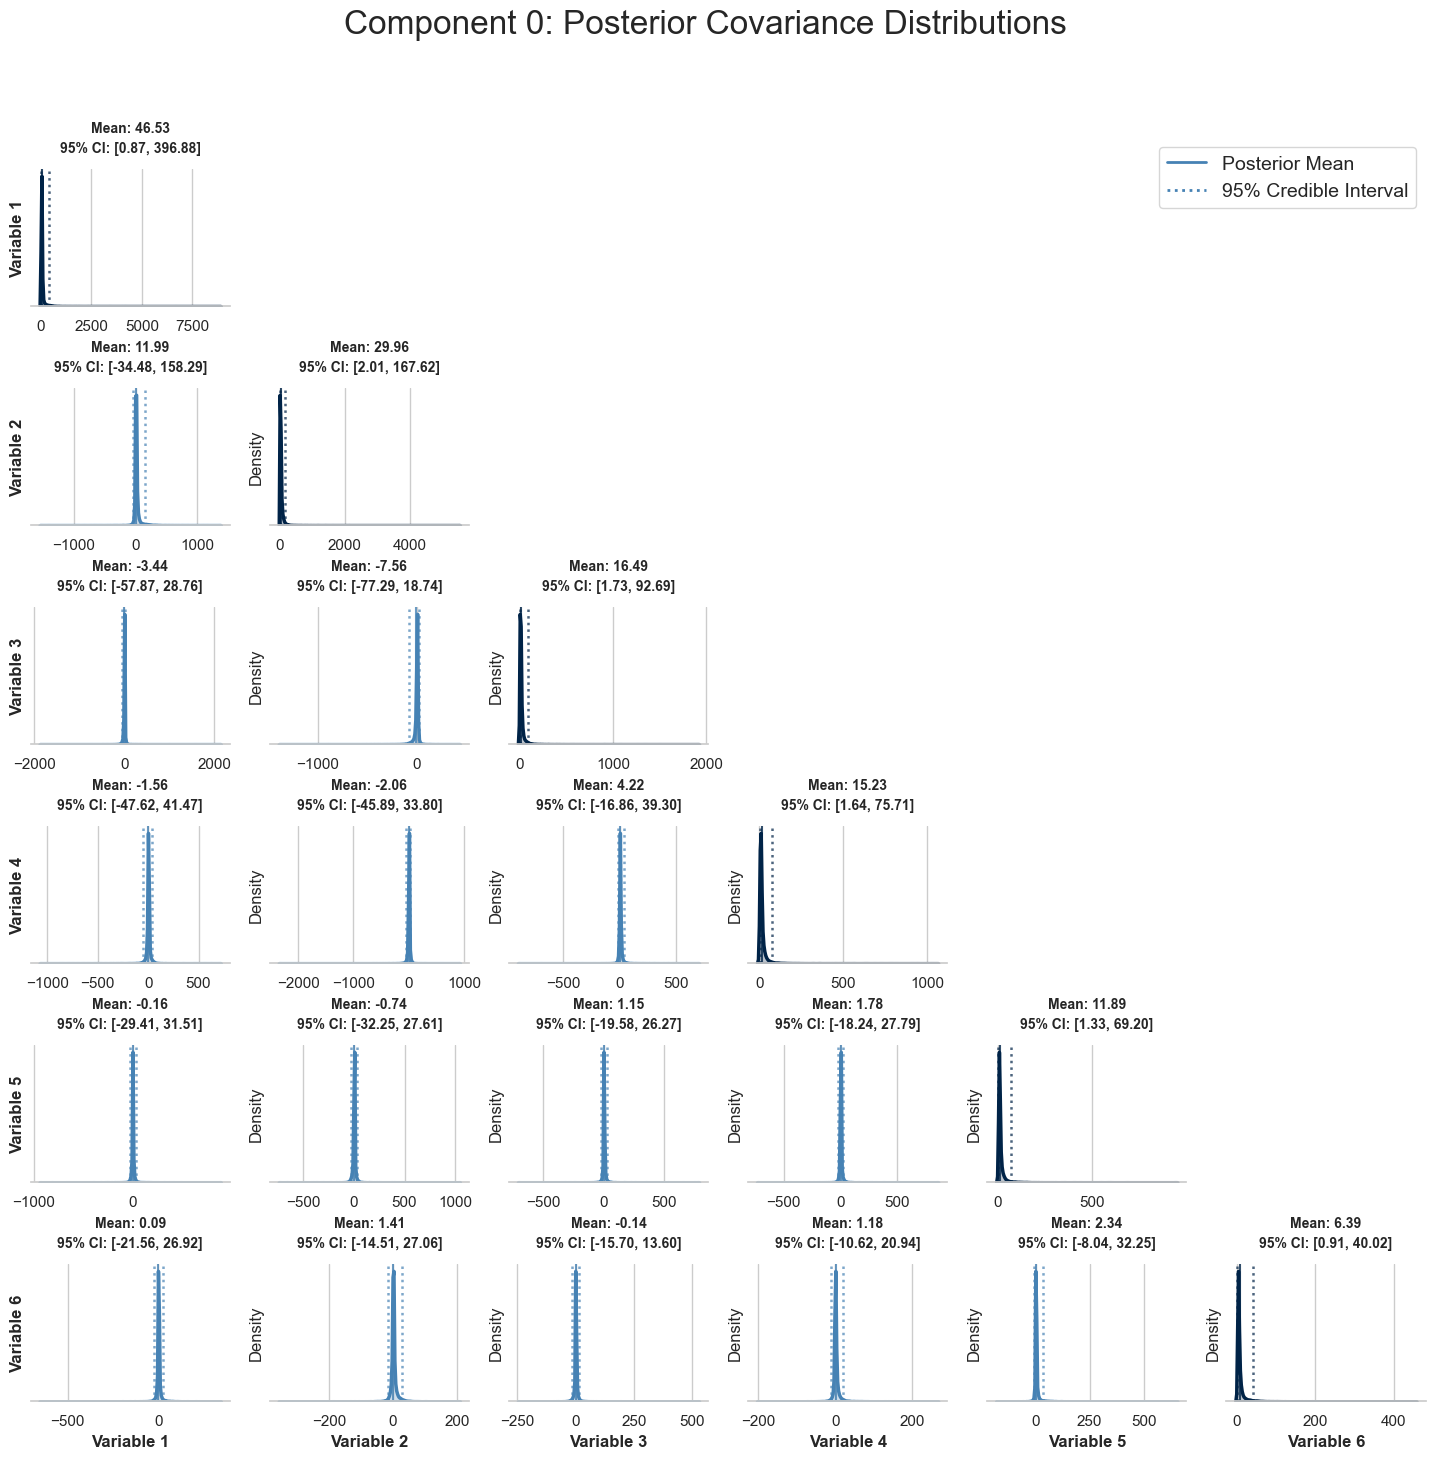

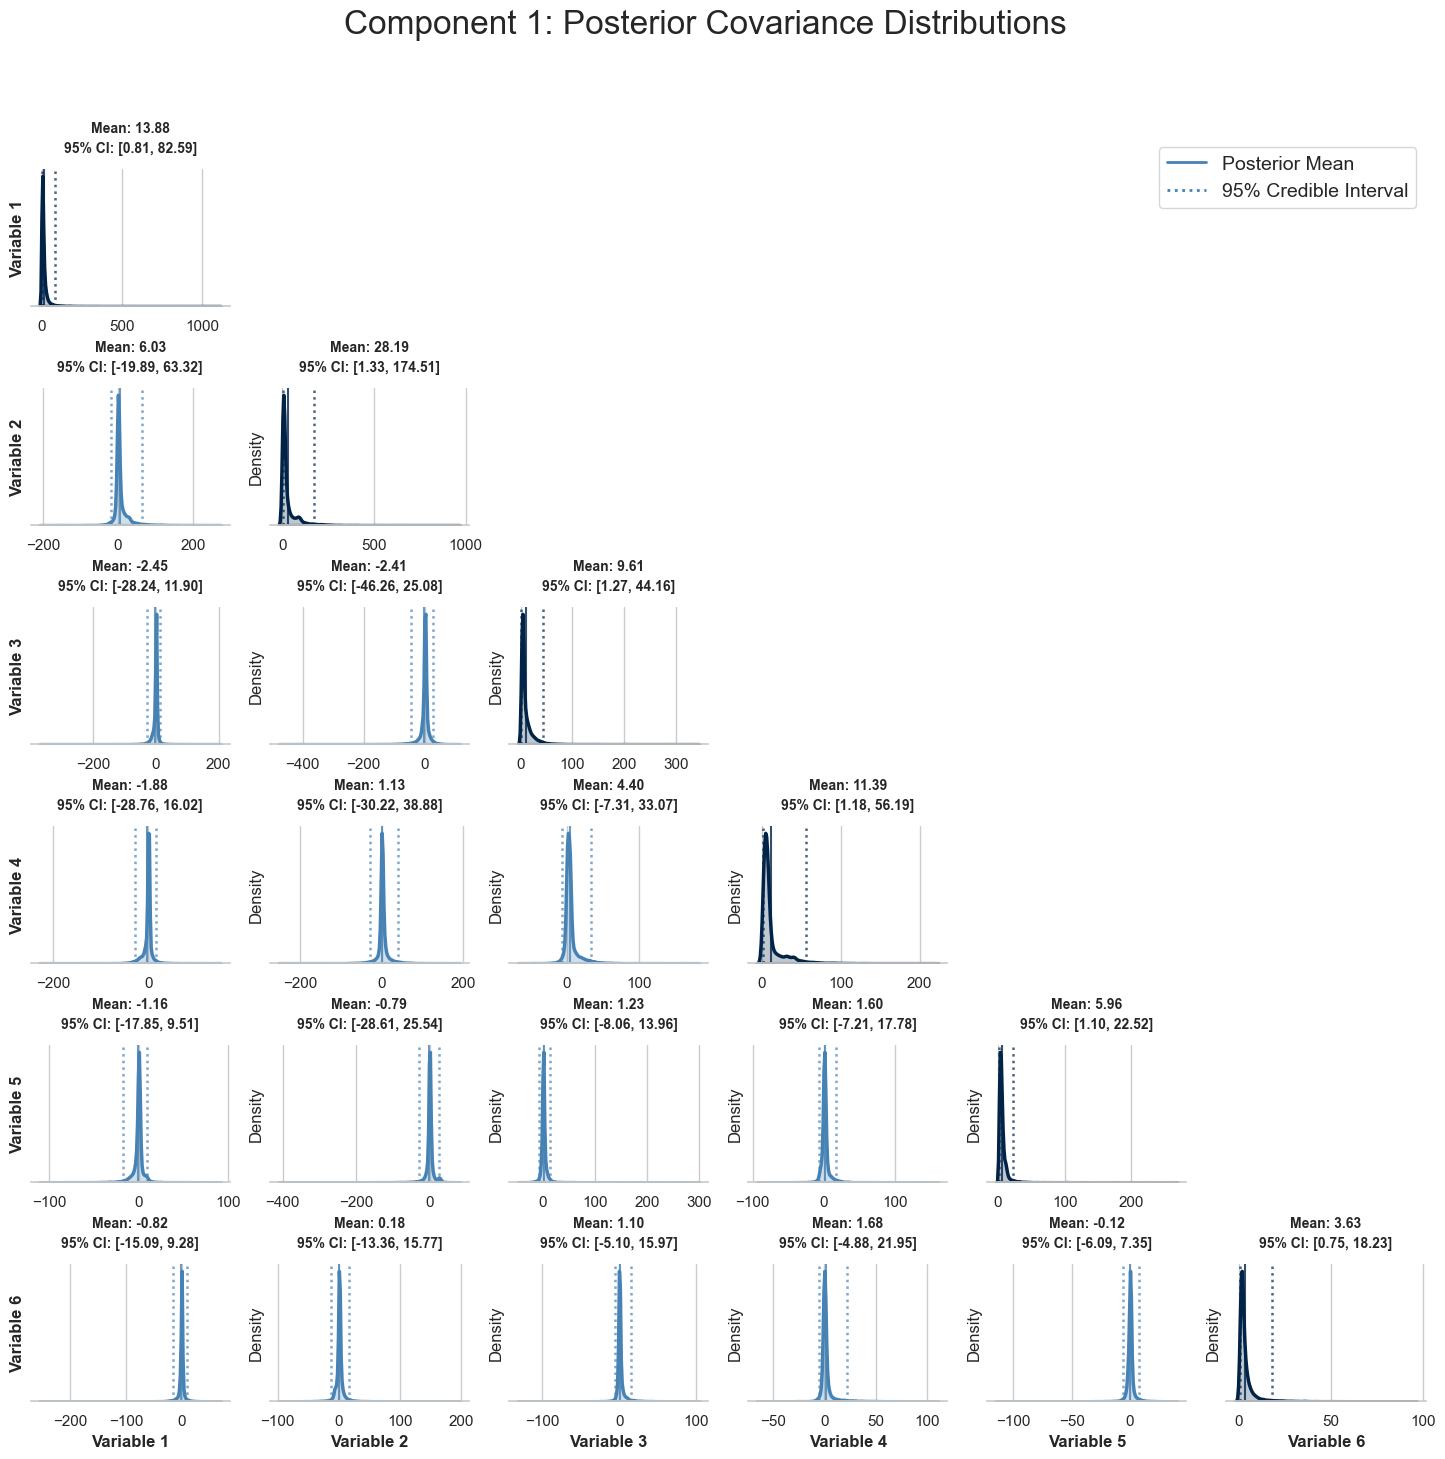

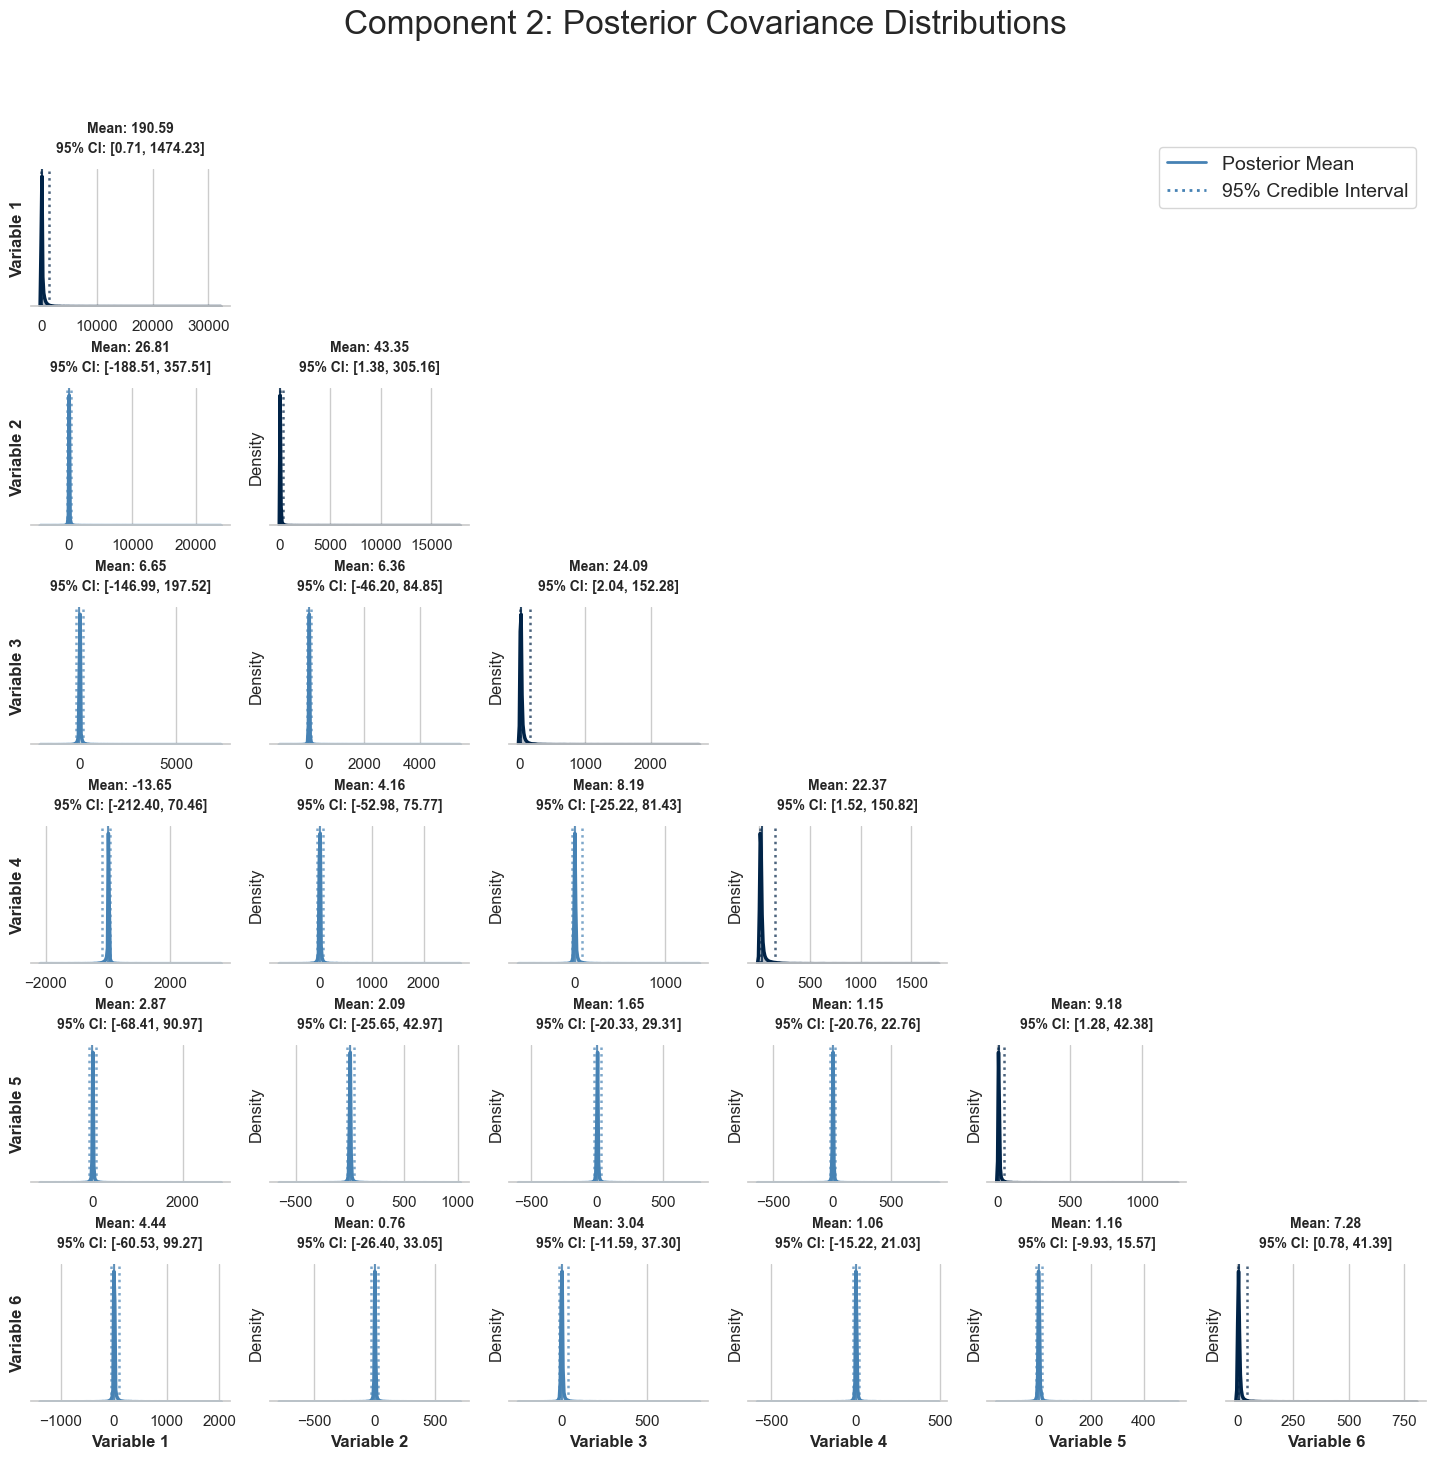

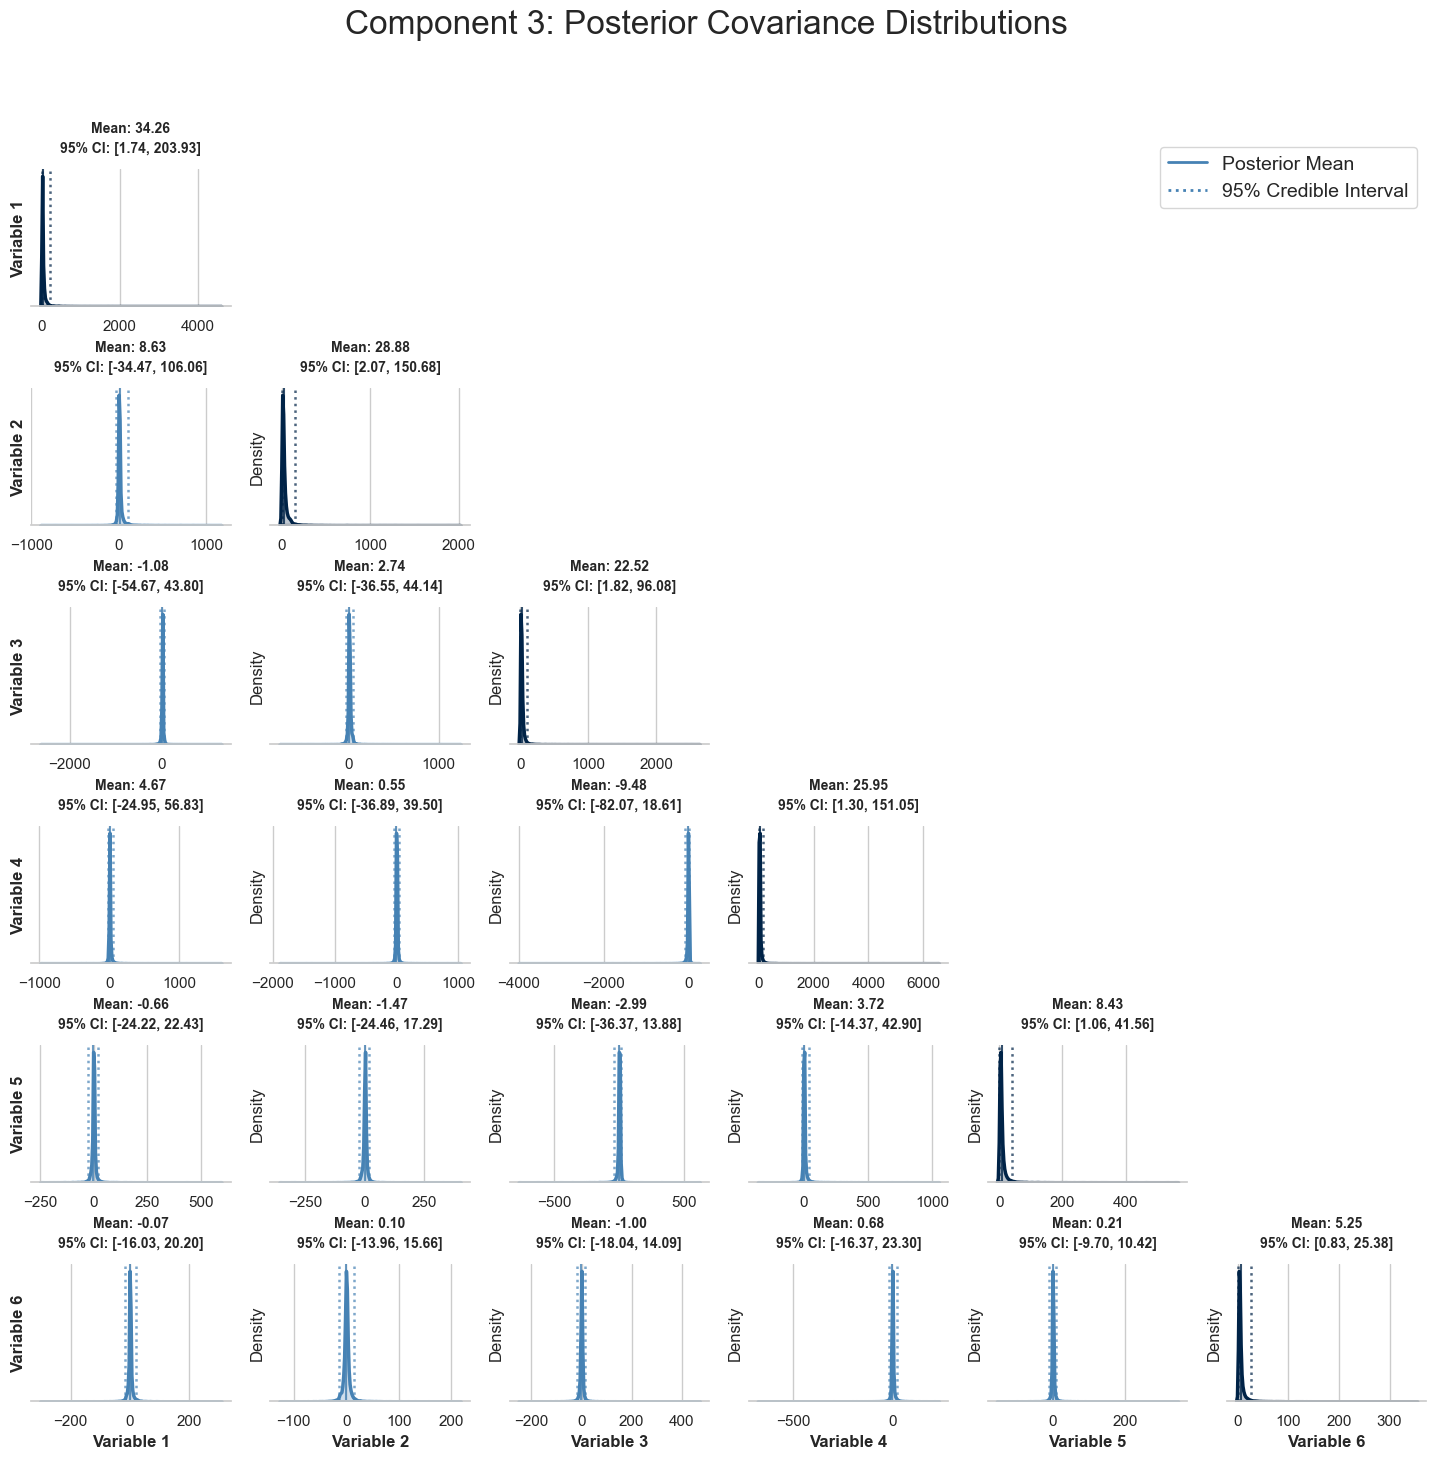

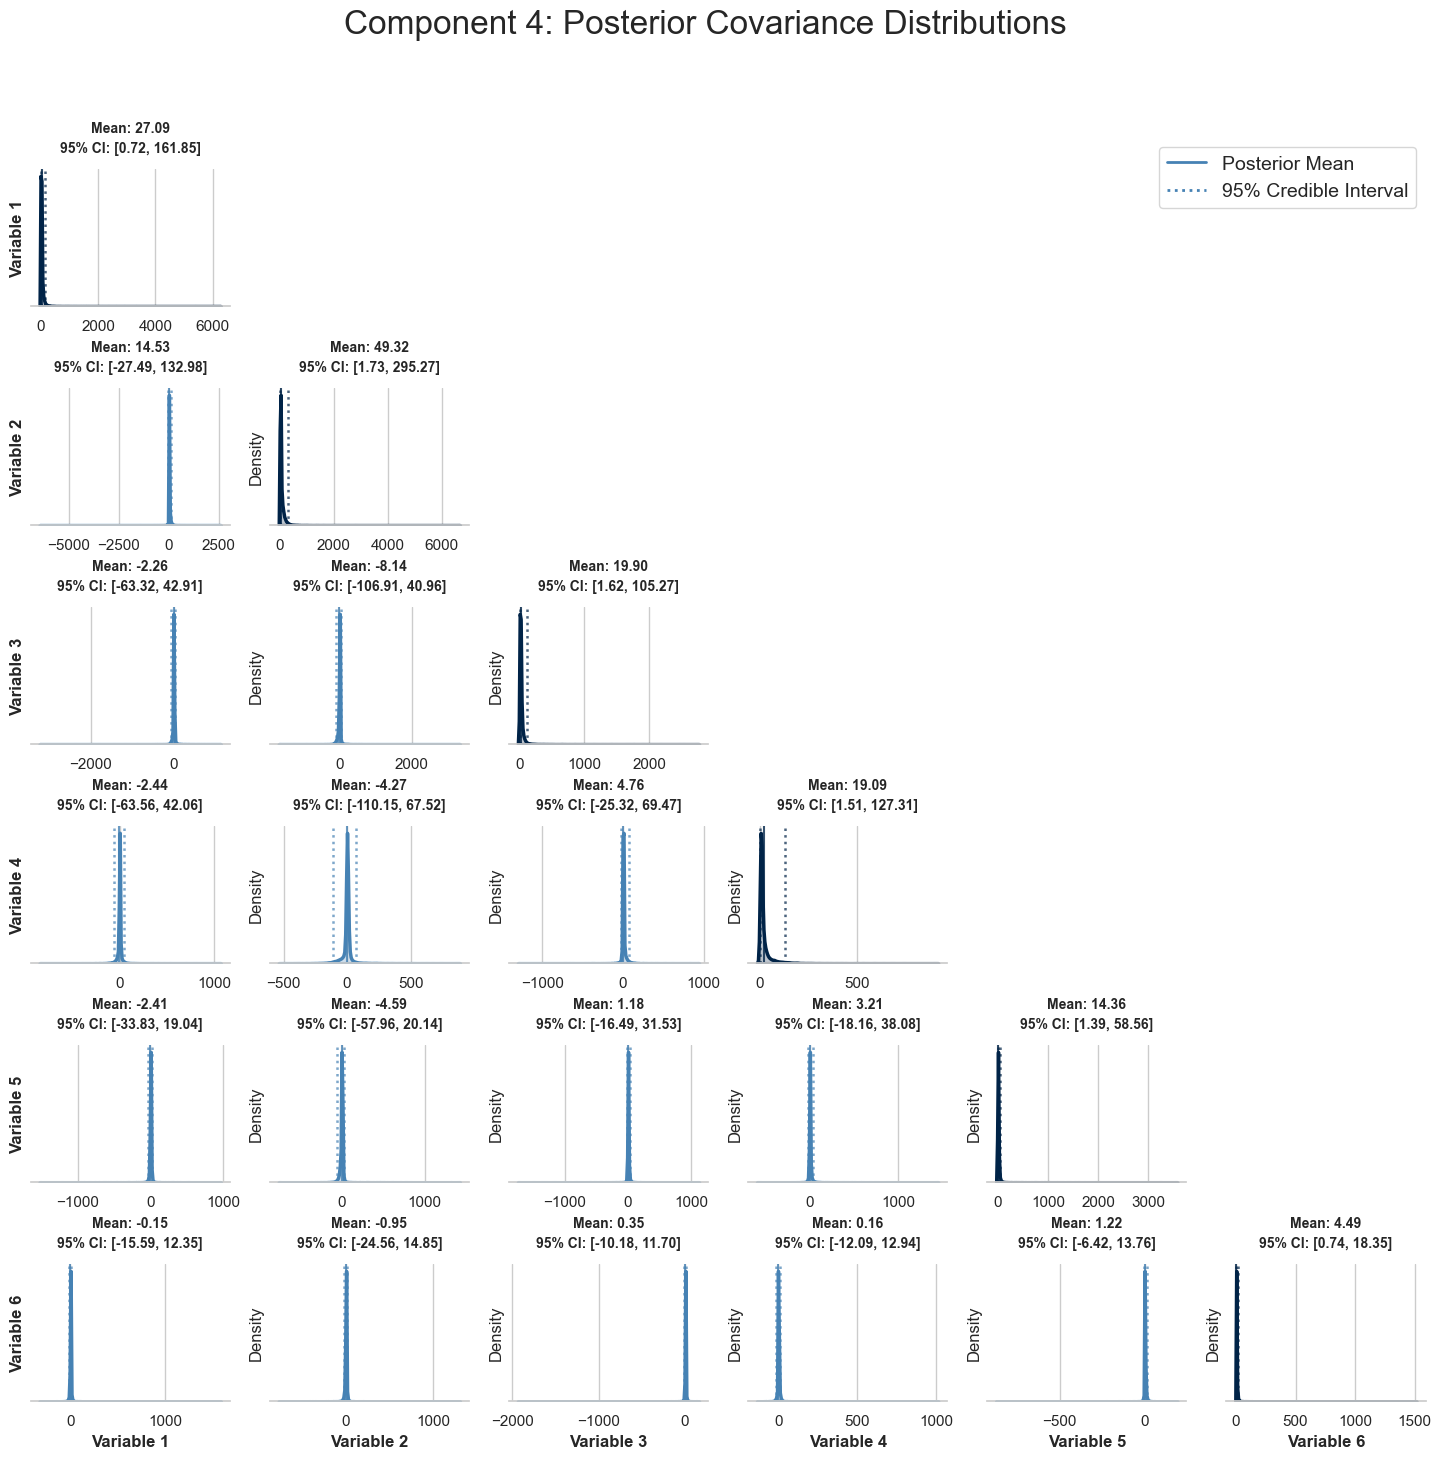

In [3]:
def plot_cholesky_traces(samples_dict, n_params, k_idx=0, param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    """Plots trace plots for the latent Cholesky factors."""
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape

    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}", alpha=0.7)
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')

            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params}", fontsize=20)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Plot Traces for each mixture component
print("Plotting Cholesky Traces...")
for k in range(K):
    plot_cholesky_traces(posterior_samples, n_params=P, k_idx=k)

# ── Covariance recovery ────────────────────────────────────────────────────────
print("\nRecovering Covariance Matrices (Sigma_k) from samples...")

bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector -> Sigma (covariance matrix)."""
    L = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)

# Vectorize across Chains, Draws, and Components
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
latent_samples_raw = posterior_samples["sigma_inv_chol_k_latent"]
sigma_samples_raw = v_latent_to_sigma(latent_samples_raw)  # Shape: (chains, draws, K, P, P)

def plot_final_covariance_empirical(samples, component_idx=0):
    """Plots the posterior distributions of the recovered covariance matrix."""
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)

    diag_color = "#002347"
    off_diag_color = "#4682B4"

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off')
                continue

            data_vec = flattened_samples[:, i, j]
            current_color = diag_color if (i == j) else off_diag_color
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])

            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-",  lw=1.5, alpha=0.8)
            ax.axvline(ci_low,    color=current_color, linestyle=":",  lw=1.8, alpha=0.7)
            ax.axvline(ci_high,   color=current_color, linestyle=":",  lw=1.8, alpha=0.7)

            title_str = f"Mean: {post_mean:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)

            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j + 1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i + 1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(f"Component {component_idx}: Posterior Covariance Distributions", fontsize=24, y=0.98)
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# Plot Covariance matrices for each component
print("\nPlotting Posterior Covariances...")
for k in range(K):
    plot_final_covariance_empirical(samples=sigma_samples_raw[:, :, k, :, :], component_idx=k)


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


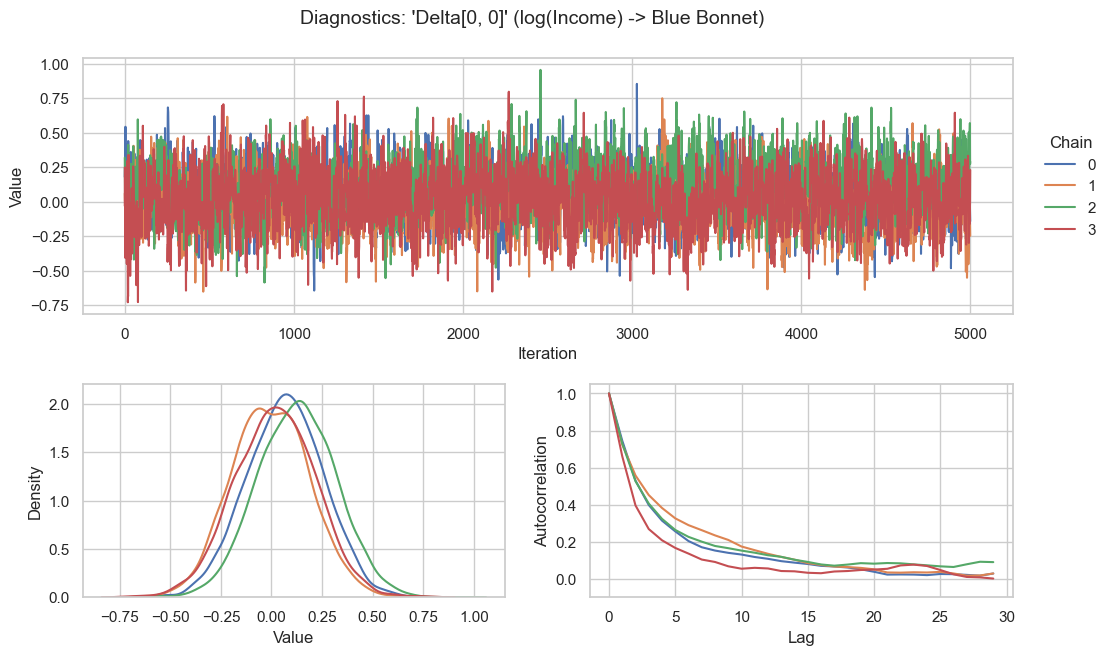

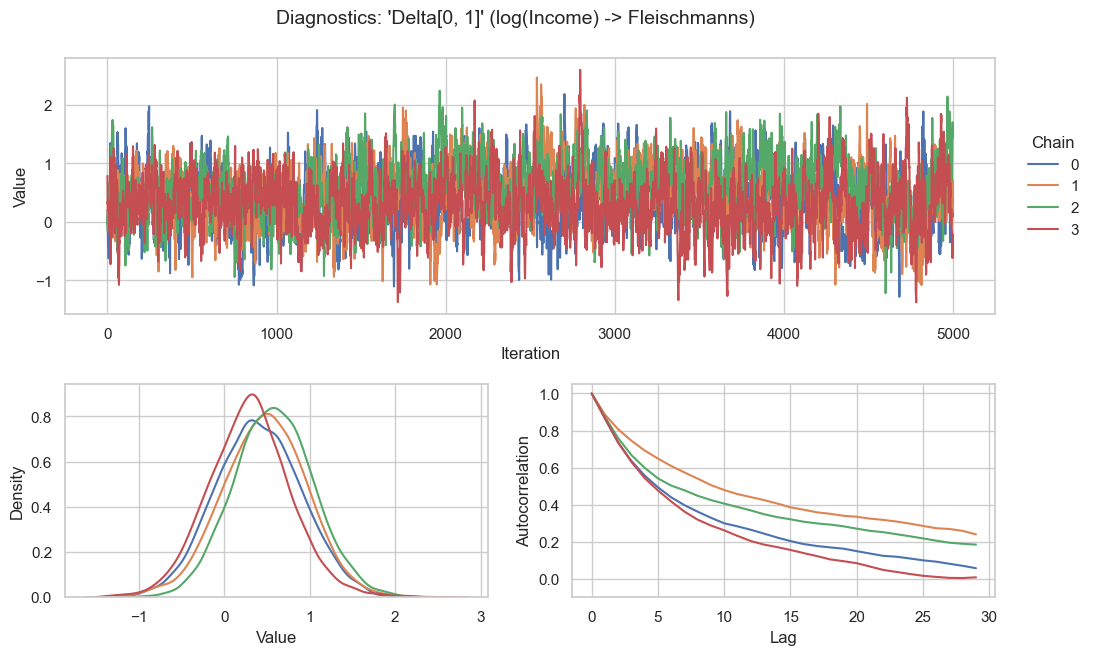

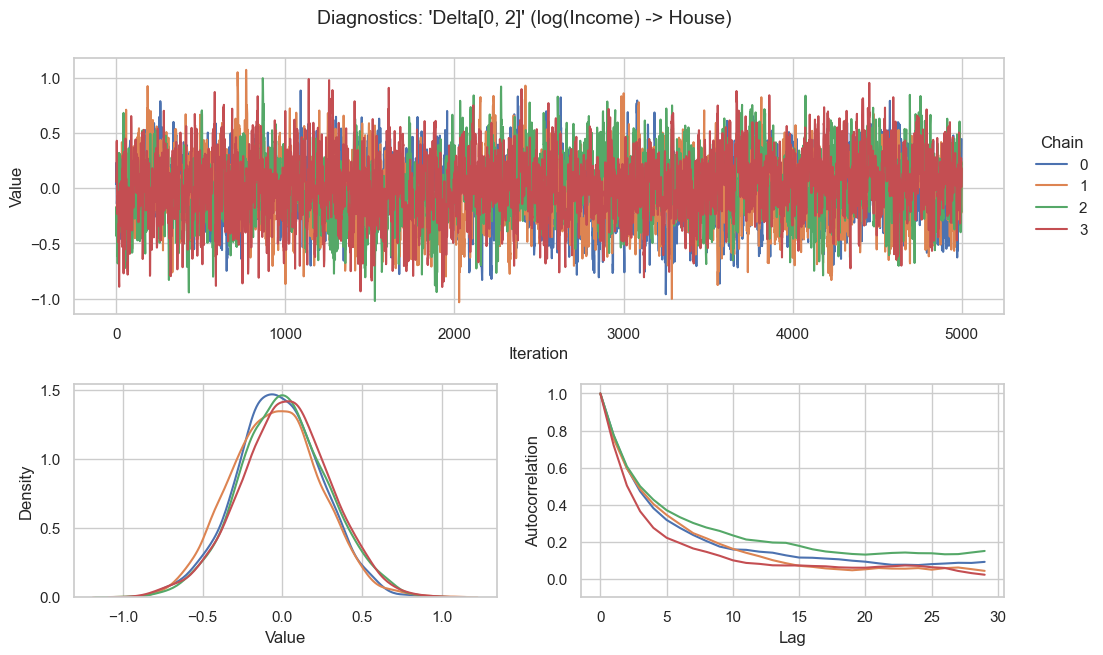

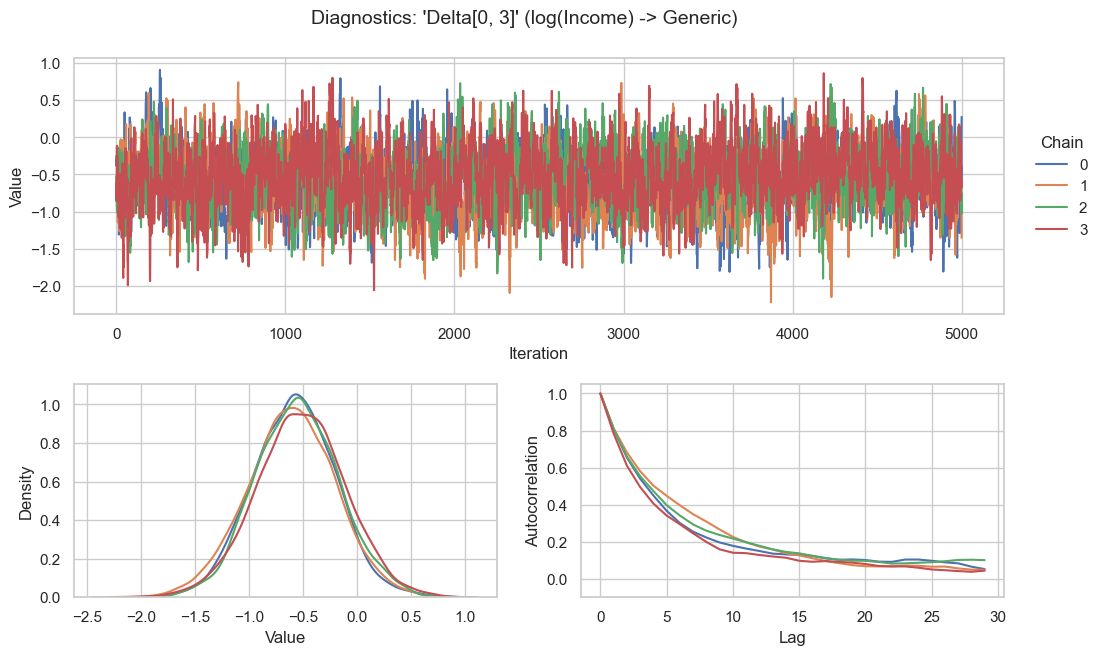

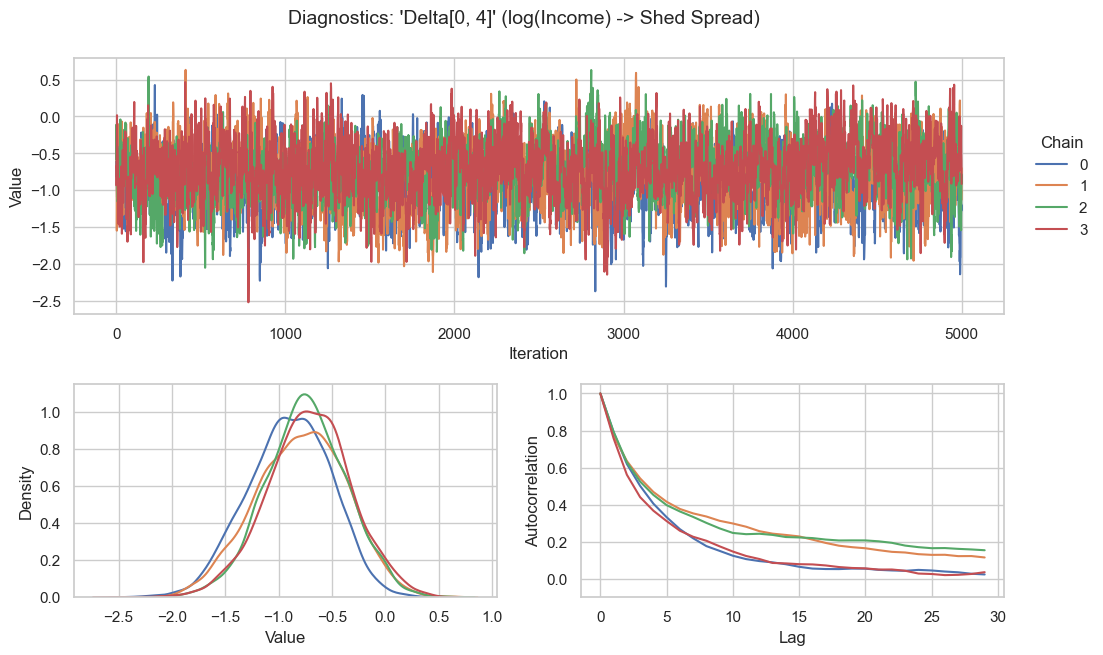

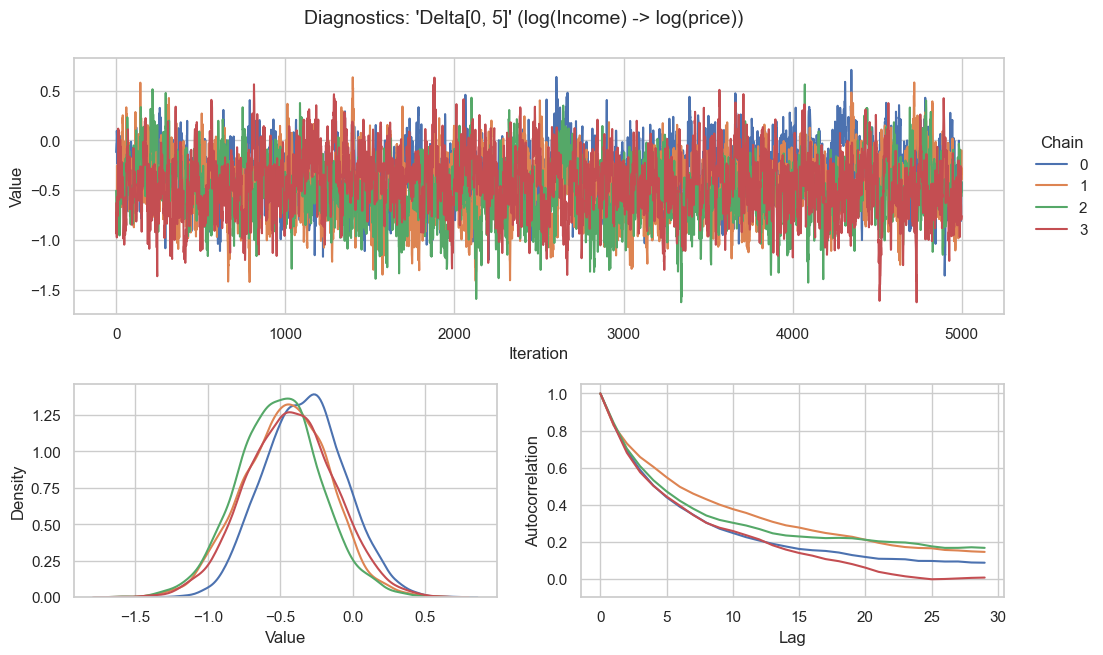

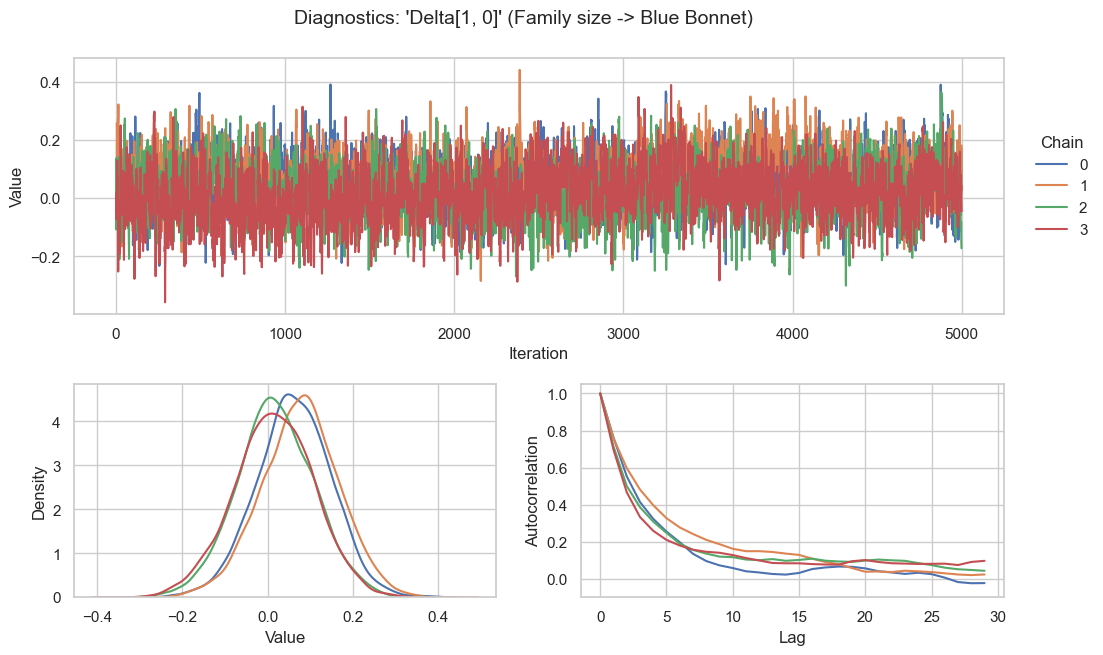

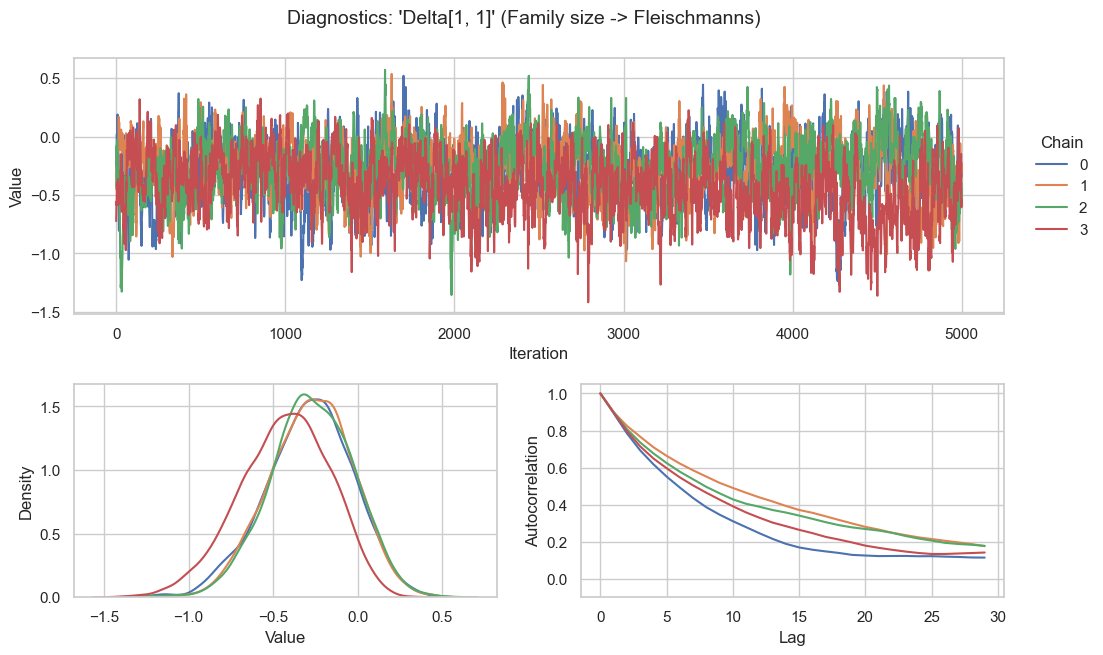

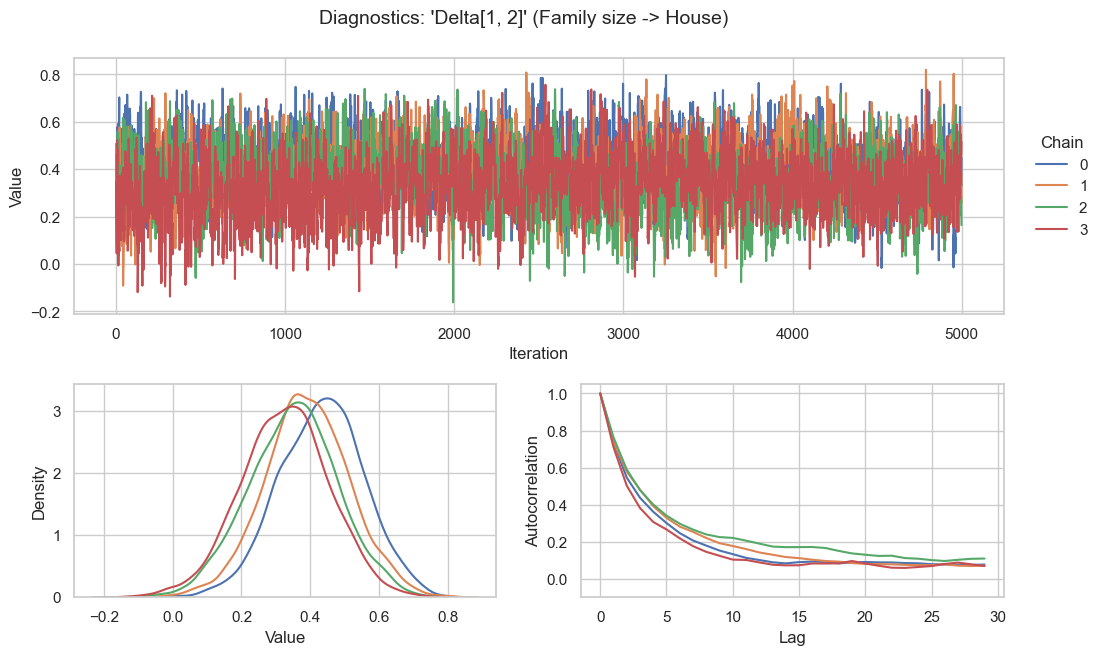

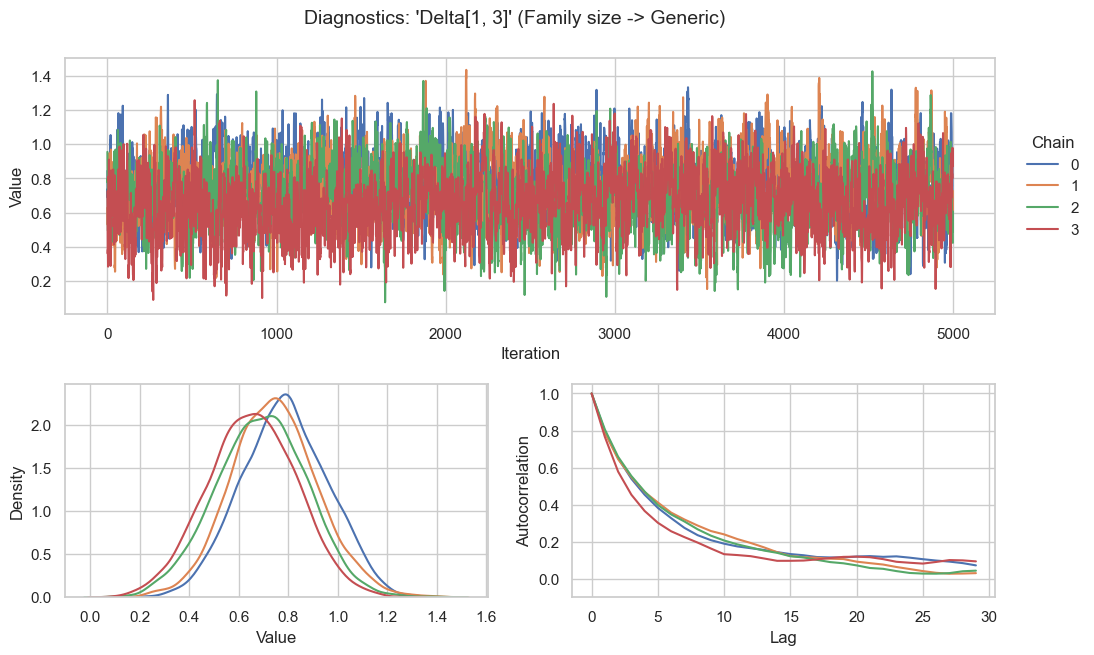

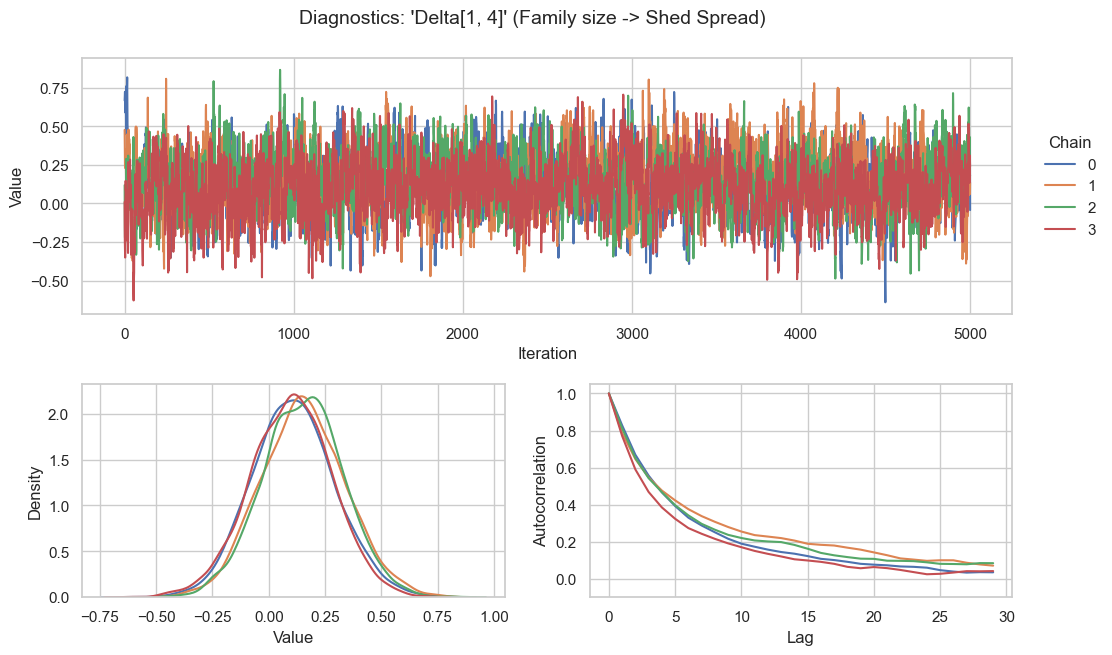

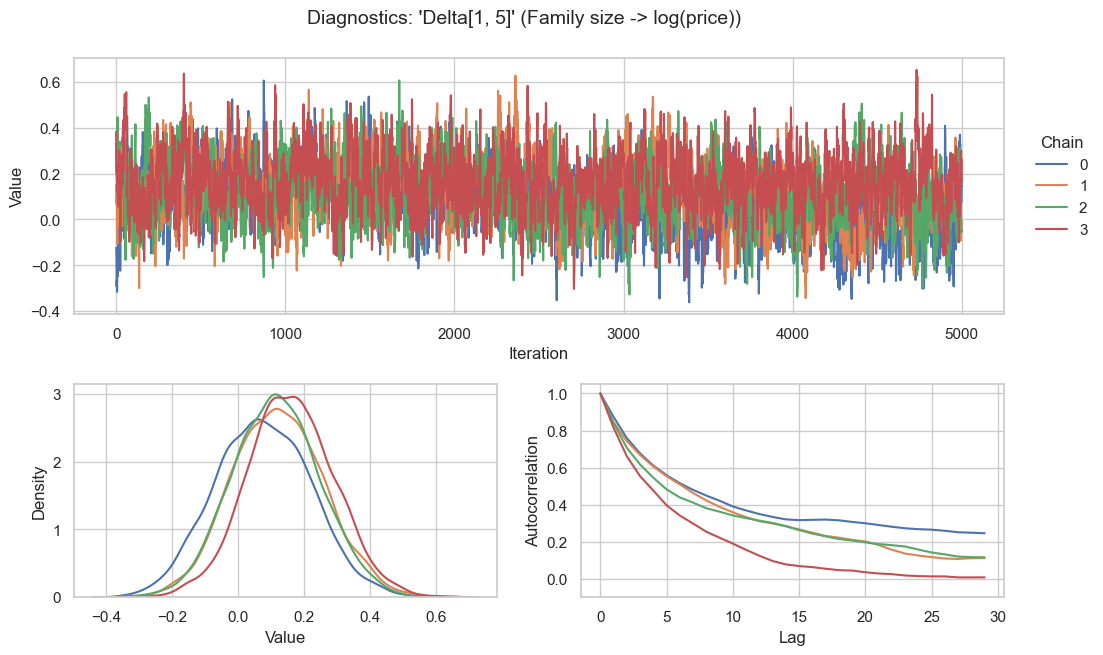

In [4]:
def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm = np.sum(x_centered ** 2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    return (acf[acf.size // 2:] / norm)[:nlags]

def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx, demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(f"Diagnostics: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})", fontsize=14, y=0.95)
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)

    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)

    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags), alpha=1)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    plt.show()

print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_samples = posterior_samples["Delta"]
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_samples, demo_idx=i, param_idx=j,
            demo_name=demo_names[i], param_name=param_names[j]
        )


=== Global Parameters (Baseline Means mu_k) Summary Tables ===

--- Raw MCMC Component 0 ---


,Posterior_Mean,Posterior_Std
Parameter,,
Blue Bonnet,9.0750,16.729300
Fleischmanns,7.7144,15.057100
House,-5.5823,12.253100
Generic,-14.1835,18.997299
Shed Spread,0.1698,14.024300
log(price),-3.5785,8.676100



--- Raw MCMC Component 1 ---


,Posterior_Mean,Posterior_Std
Parameter,,
Blue Bonnet,-1.1040,2.5595
Fleischmanns,-5.0355,9.8880
House,-7.4418,6.2342
Generic,-9.9314,4.8551
Shed Spread,-5.0908,6.9998
log(price),-5.5265,3.9827



--- Raw MCMC Component 2 ---


...


--- Raw MCMC Component 4 ---


,Posterior_Mean,Posterior_Std
Parameter,,
Blue Bonnet,-4.2815,21.639400
Fleischmanns,-8.4629,25.076900
House,-8.1716,21.947500
Generic,-8.3924,16.384501
Shed Spread,4.6757,15.884500
log(price),-0.9990,8.103000



=== Posterior distribution of Delta (mean + std) ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
log(Income),0.05 (0.20),0.44 (0.50),-0.01 (0.28),-0.56 (0.40),-0.79 (0.40),-0.43 (0.30)
Family size,0.04 (0.09),-0.32 (0.26),0.38 (0.13),0.72 (0.18),0.13 (0.19),0.12 (0.14)



Plotting Delta Distributions...


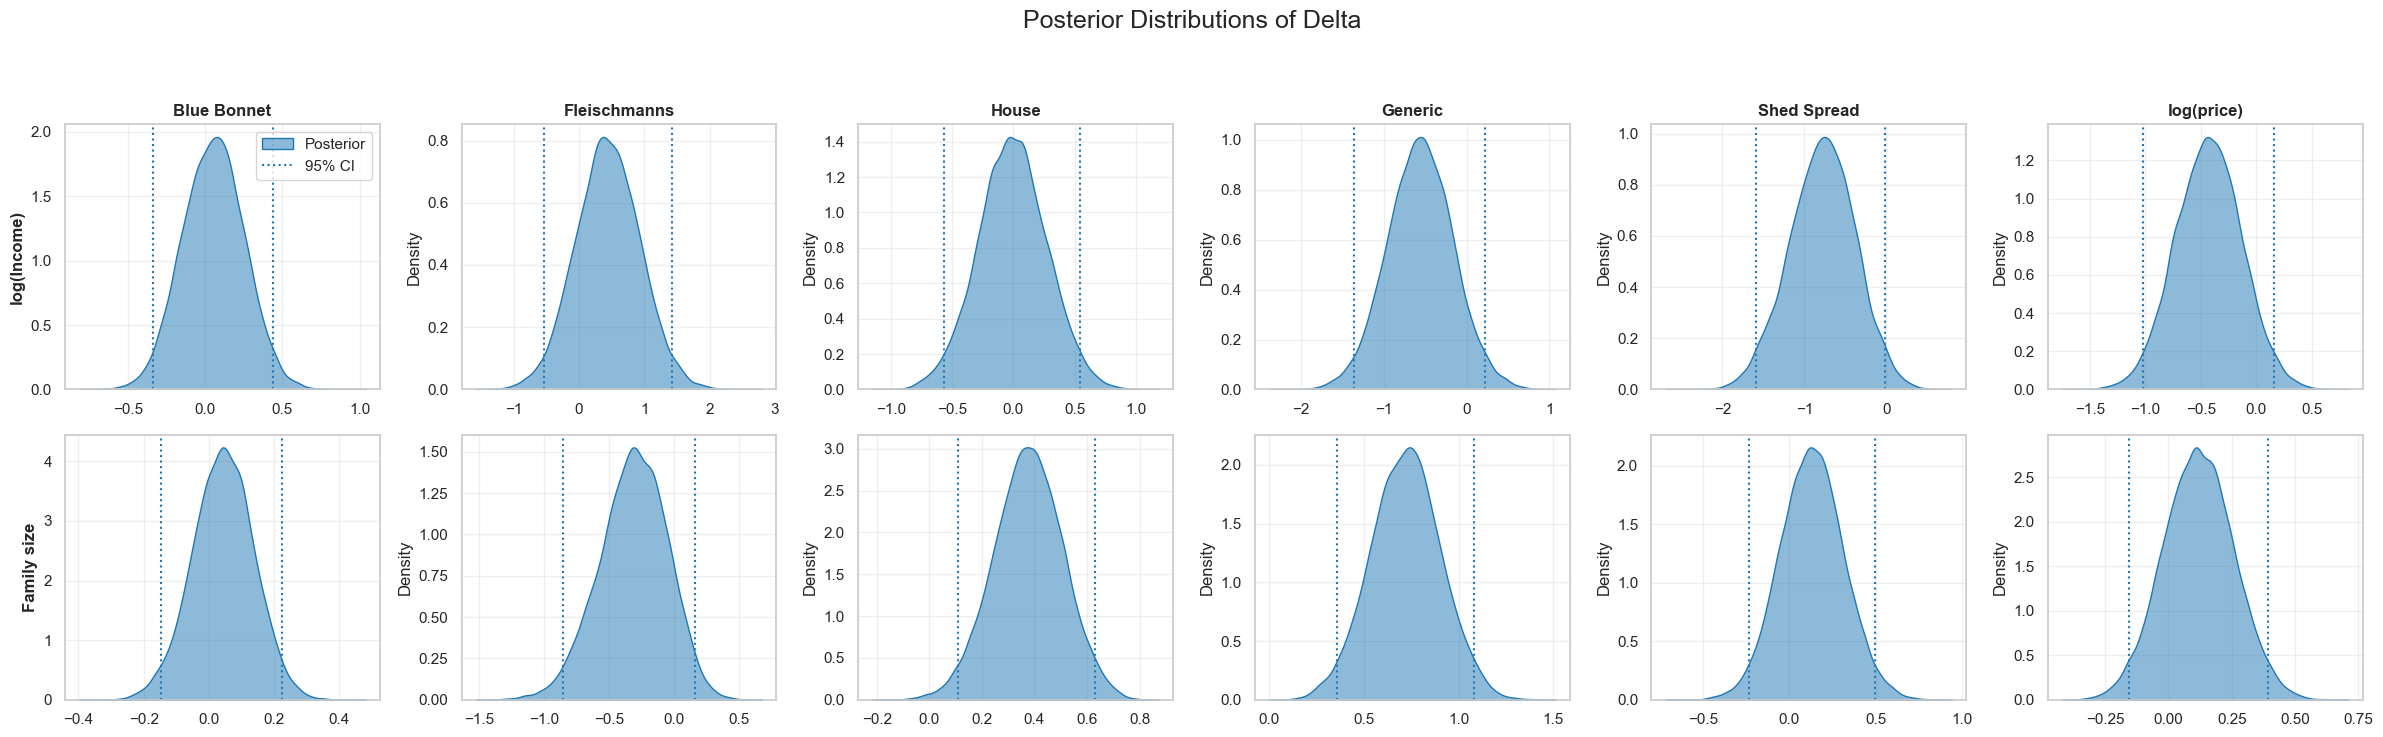

In [5]:
def create_summary_table(post_mu, p_names):
    """Creates a summary dataframe for posterior means and stds."""
    return pd.DataFrame({
        'Parameter':      p_names,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Posterior_Std':  post_mu.std(axis=0)
    }).round(4).set_index("Parameter")

print("\n=== Global Parameters (Baseline Means mu_k) Summary Tables ===")
mu_samples_raw = posterior_samples["mu_k"]
mu_samples_raw_flat = mu_samples_raw.reshape(-1, K, P)

for k in range(K):
    print(f"\n--- Raw MCMC Component {k} ---")
    display(create_summary_table(post_mu=mu_samples_raw_flat[:, k, :], p_names=param_names))

# ── Delta Summaries ───────────────────────────────────────────────────────────

def generate_delta_table(delta_draws, p_names, d_names):
    """Formats Delta means and standard deviations into a grid."""
    mean = np.mean(delta_draws, axis=0)
    std  = np.std(delta_draws,  axis=0)
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]:.2f} ({std[i, j]:.2f})"
    return df

delta_samples_raw = posterior_samples["Delta"].reshape(-1, D, P)

print("\n=== Posterior distribution of Delta (mean + std) ===")
display(generate_delta_table(delta_samples_raw, param_names, demo_names))

def plot_delta_distributions(delta_samples, p_names, d_names):
    """Plots KDEs for each parameter in the Delta matrix."""
    n_demos, n_params = len(d_names), len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4 * n_params, 3.5 * n_demos))
    
    if n_demos == 1 and n_params == 1:
        axes = np.array([[axes]])
    elif n_demos == 1:
        axes = axes[None, :]
    elif n_params == 1:
        axes = axes[:, None]

    for d in range(n_demos):
        for p in range(n_params):
            ax      = axes[d, p]
            samples = delta_samples[:, d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior")
            ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)

            if d == 0:
                ax.set_title(p_names[p], fontweight='bold')
            if p == 0:
                ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)

            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions of Delta", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_raw, param_names, demo_names)

In [6]:
import numpy as np
import tensorflow_probability.substrates.jax.bijectors as tfb

def align_draws_by_pvec_order(samples):
    """
    Aligns mixture components for every single MCMC draw by enforcing the 
    strict ordering constraint: pvec_0 > pvec_1 > ... > pvec_K
    """
    # Create a clean copy, dropping pvec_latent as it cannot be sorted
    aligned = {key: np.copy(val) for key, val in samples.items() if key != "pvec_latent"}
    
    # 1. Recover the simplex probabilities
    if "pvec" in samples:
        pvec_draws = samples["pvec"]
    else:
        pvec_latent = samples["pvec_latent"]
        pvec_draws = np.array(tfb.SoftmaxCentered().forward(pvec_latent))
        
    n_chains, n_draws, K = pvec_draws.shape
    
    # 2. Get the sorting indices for EVERY single draw (descending order)
    sort_idx = np.argsort(pvec_draws, axis=-1)[..., ::-1]
    
    # 3. Apply the sort to pvec
    aligned["pvec"] = np.take_along_axis(pvec_draws, sort_idx, axis=2)
    
    # 4. Apply the sort to mu_k (shape: chains, draws, K, P)
    sort_idx_mu = sort_idx[:, :, :, np.newaxis] 
    sort_idx_mu = np.broadcast_to(sort_idx_mu, samples["mu_k"].shape)
    aligned["mu_k"] = np.take_along_axis(samples["mu_k"], sort_idx_mu, axis=2)
    
    # 5. Apply the sort to sigma_inv_chol_k_latent (shape: chains, draws, K, n_latent)
    # FIX: Only ONE newaxis needed because it's a 1D vector at this stage, not a 2D matrix
    sort_idx_sigma = sort_idx[:, :, :, np.newaxis]
    sort_idx_sigma = np.broadcast_to(sort_idx_sigma, samples["sigma_inv_chol_k_latent"].shape)
    aligned["sigma_inv_chol_k_latent"] = np.take_along_axis(
        samples["sigma_inv_chol_k_latent"], sort_idx_sigma, axis=2
    )
    
    return aligned

# Run the strict draw-by-draw alignment
aligned_samples = align_draws_by_pvec_order(posterior_samples)
print("All individual MCMC draws successfully aligned based on strict pvec ordering!")

All individual MCMC draws successfully aligned based on strict pvec ordering!


Posterior mean pvec: [0.23278806 0.25422487 0.22973166 0.05983572 0.22342102]

=== pvec: Posterior Summary ===


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%
Component,,,,
0,0.2328,0.3254,0.0091,0.8732
1,0.2542,0.2593,0.0437,0.7451
2,0.2297,0.2945,0.0071,0.7718
3,0.0598,0.0468,0.0072,0.1641
4,0.2234,0.2568,0.0111,0.7144



=== pvec: Goose-Style Chain Diagnostics ===


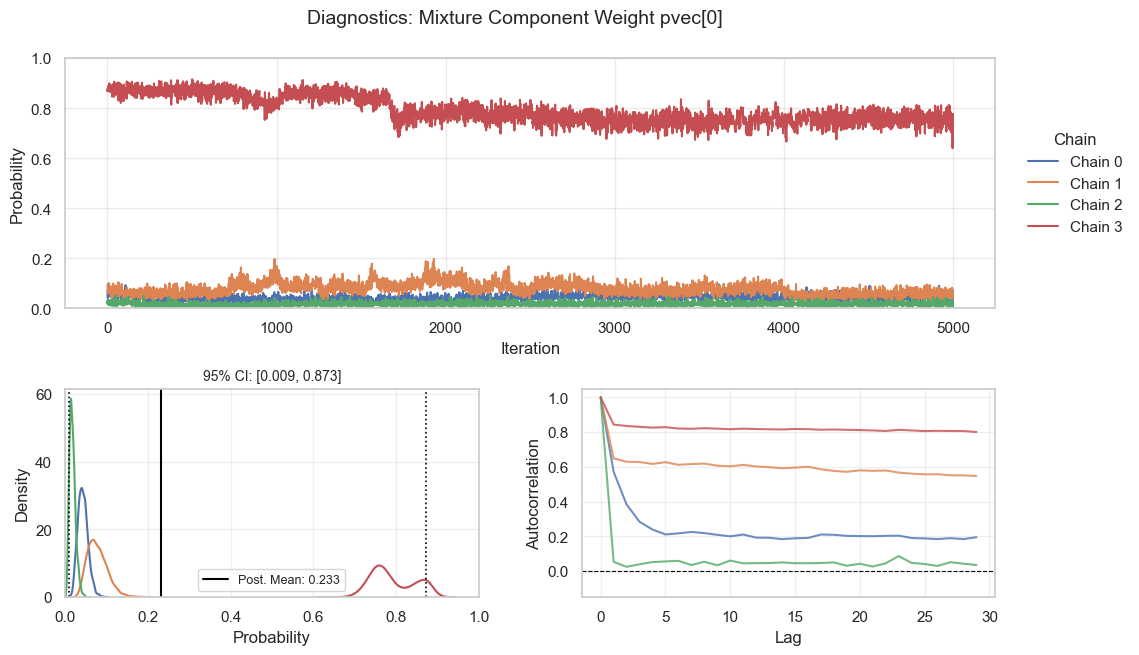

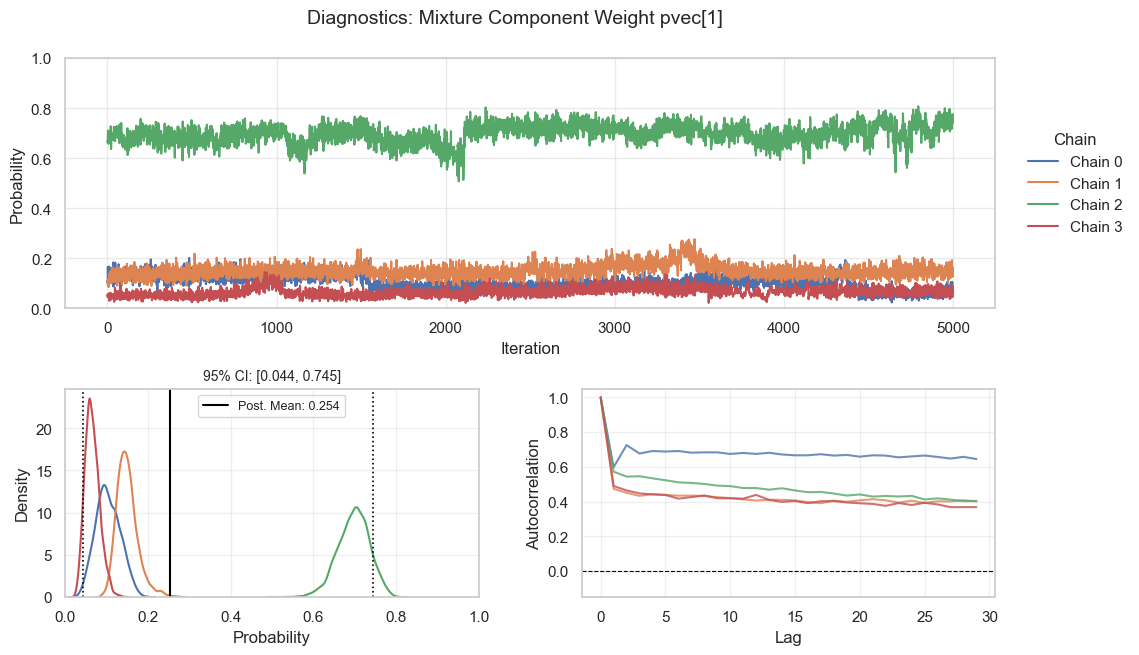

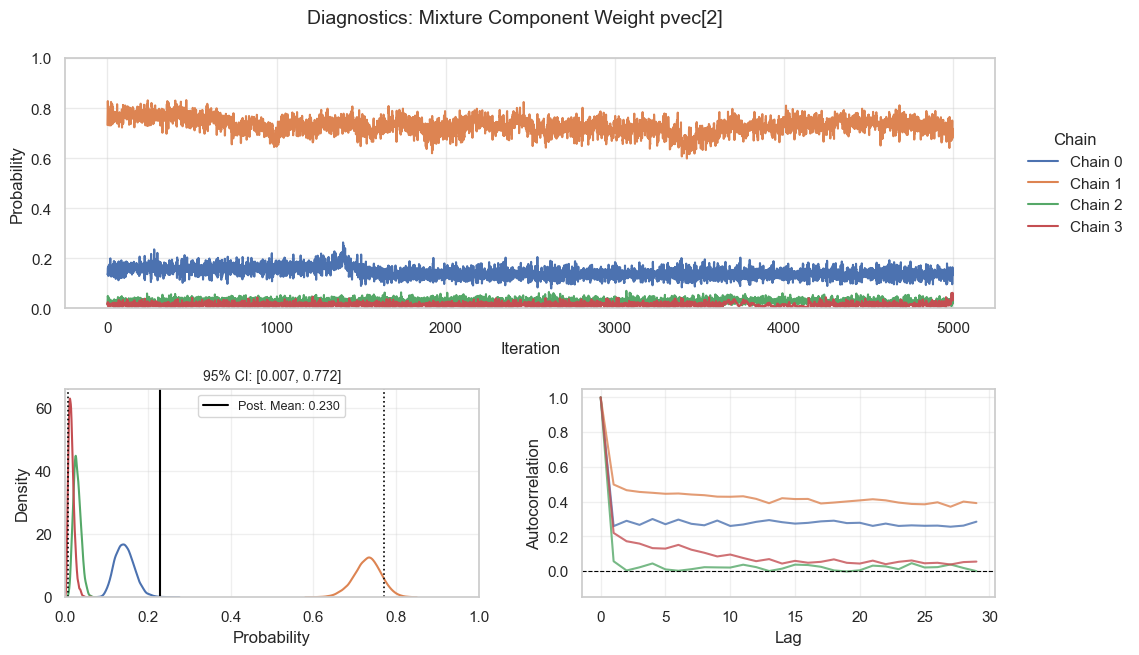

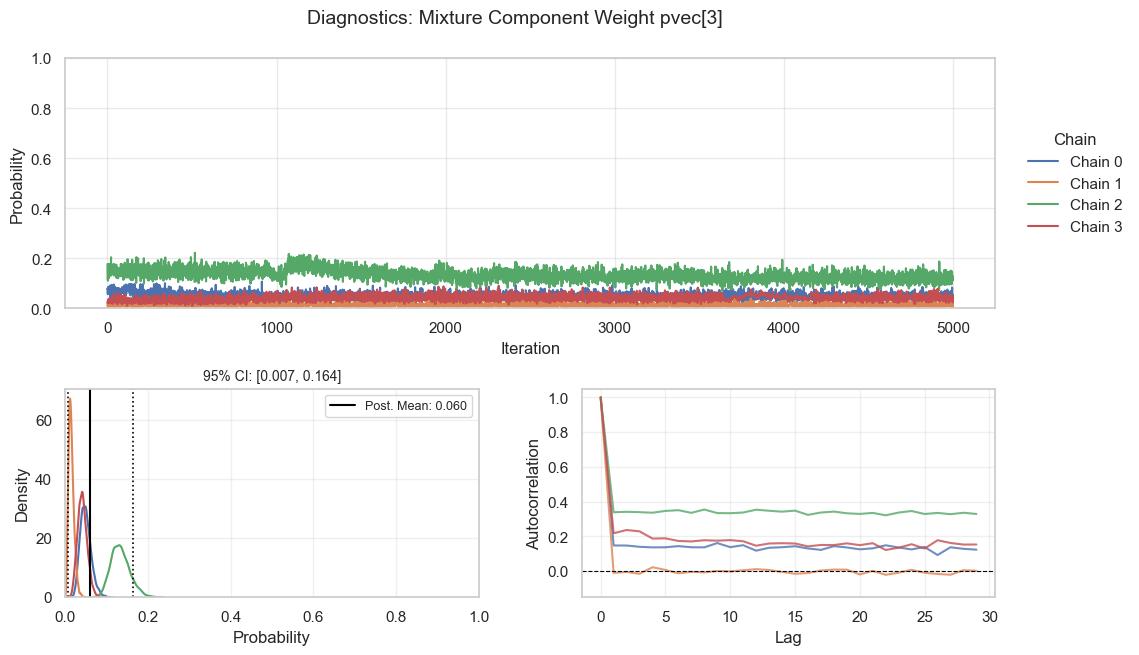

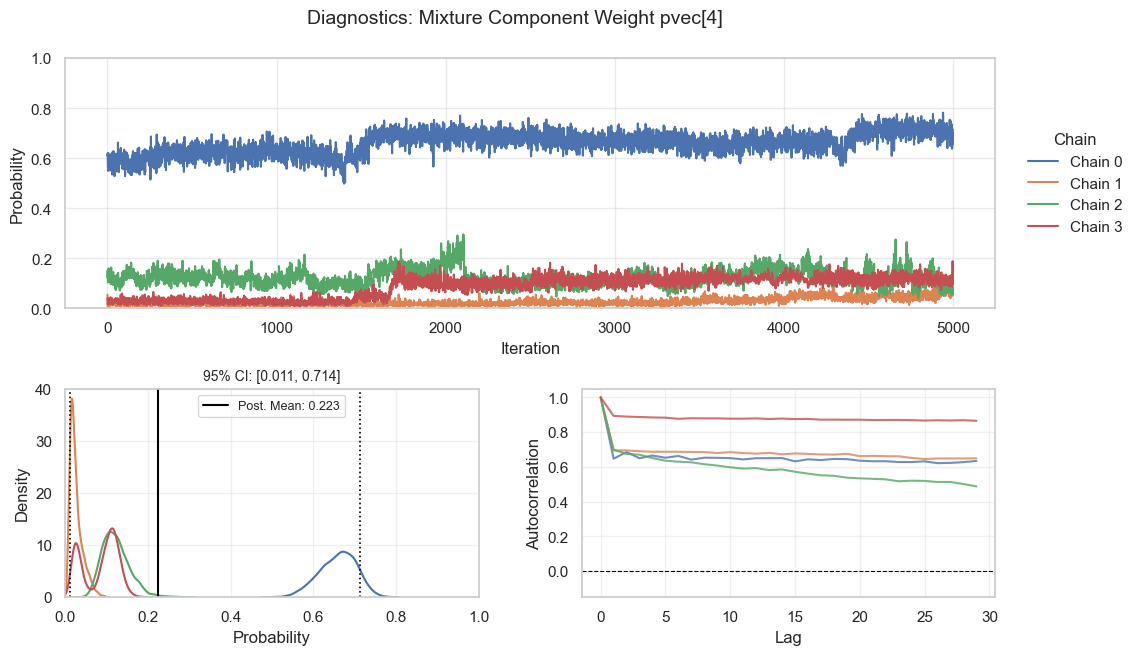

In [7]:
# Transform latent pvec back to simplex if needed, but if 'pvec' is already saved, use it directly
# Based on your previous save, 'pvec' might need recalculation if it wasn't natively tracked. 
# Assuming 'pvec_latent' was the tracked parameter in the kernel, let's map it.
if "pvec" not in posterior_samples:
    m = posterior_samples["pvec_latent"].shape[0] * posterior_samples["pvec_latent"].shape[1]
    pvec_simplex = np.array(tfb.SoftmaxCentered().forward(posterior_samples["pvec_latent"]))
    pvec_samples_raw = pvec_simplex.reshape(posterior_samples["pvec_latent"].shape[0], posterior_samples["pvec_latent"].shape[1], K)
else:
    pvec_samples_raw = posterior_samples["pvec"]

flat_pvec = pvec_samples_raw.reshape(-1, K)
print("Posterior mean pvec:", flat_pvec.mean(axis=0))

def plot_pvec_diagnostics(pvec_samples_array, K, n_lags=30):
    """Goose-style trace / density / ACF for each mixture weight."""
    n_chains, n_draws, _ = pvec_samples_array.shape

    for k in range(K):
        fig = plt.figure(figsize=(12, 7))
        fig.suptitle(f"Diagnostics: Mixture Component Weight pvec[{k}]", fontsize=14, y=0.95)
        gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.35, wspace=0.25)

        # 1. Trace Plot
        ax_trace = fig.add_subplot(gs_layout[0, :])
        for chain in range(n_chains):
            ax_trace.plot(pvec_samples_array[chain, :, k], label=f"Chain {chain}")
        ax_trace.set_xlabel("Iteration")
        ax_trace.set_ylabel("Probability")
        ax_trace.set_ylim(0, 1)
        ax_trace.grid(True, alpha=0.4)
        ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

        # 2. Density Plot
        ax_dens = fig.add_subplot(gs_layout[1, 0])
        all_draws = pvec_samples_array[:, :, k].reshape(-1)
        post_mean = all_draws.mean()
        ci_low, ci_high = np.percentile(all_draws, [2.5, 97.5])

        for chain in range(n_chains):
            sns.kdeplot(pvec_samples_array[chain, :, k], ax=ax_dens, fill=False)
        ax_dens.axvline(post_mean,    color="black", linestyle="-",  lw=1.5, label=f"Post. Mean: {post_mean:.3f}")
        ax_dens.axvline(ci_low,       color="black", linestyle=":",  lw=1.2)
        ax_dens.axvline(ci_high,      color="black", linestyle=":",  lw=1.2)
        
        ax_dens.set_xlabel("Probability")
        ax_dens.set_ylabel("Density")
        ax_dens.set_xlim(0, 1)
        ax_dens.legend(fontsize=9)
        ax_dens.grid(True, alpha=0.3)
        ax_dens.set_title(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]", fontsize=10)

        # 3. Autocorrelation Plot
        ax_acf = fig.add_subplot(gs_layout[1, 1])
        for chain in range(n_chains):
            ax_acf.plot(compute_acf(pvec_samples_array[chain, :, k], nlags=n_lags), alpha=0.8, label=f"Chain {chain}")
        ax_acf.axhline(0, color="black", lw=0.8, linestyle="--")
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylabel("Autocorrelation")
        ax_acf.set_ylim(-0.15, 1.05)
        ax_acf.grid(True, alpha=0.3)

        plt.show()

def pvec_summary_table(pvec_samples_array, K):
    """Generates a summary DataFrame for the mixture component weights."""
    flat = pvec_samples_array.reshape(-1, K)
    rows = []
    for k in range(K):
        draws = flat[:, k]
        ci_low, ci_high = np.percentile(draws, [2.5, 97.5])
        rows.append({
            "Component":      k,
            "Posterior_Mean": draws.mean(),
            "Posterior_Std":  draws.std(),
            "CI_2.5%":        ci_low,
            "CI_97.5%":       ci_high
        })
    return pd.DataFrame(rows).set_index("Component").round(4)

print("\n=== pvec: Posterior Summary ===")
display(pvec_summary_table(pvec_samples_raw, K))

print("\n=== pvec: Goose-Style Chain Diagnostics ===")
plot_pvec_diagnostics(pvec_samples_raw, K)

Posterior mean pvec (Aligned): [0.72028315 0.13438743 0.08767231 0.036935   0.02072072]

=== ALIGNED pvec: Posterior Summary ===


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%
Component,,,,
0,0.7203,0.0650,0.5956,0.8732
1,0.1344,0.0344,0.0511,0.1968
2,0.0877,0.0299,0.0338,0.1454
3,0.0369,0.0151,0.0137,0.0691
4,0.0207,0.0125,0.0055,0.0508



=== ALIGNED pvec: Goose-Style Chain Diagnostics ===


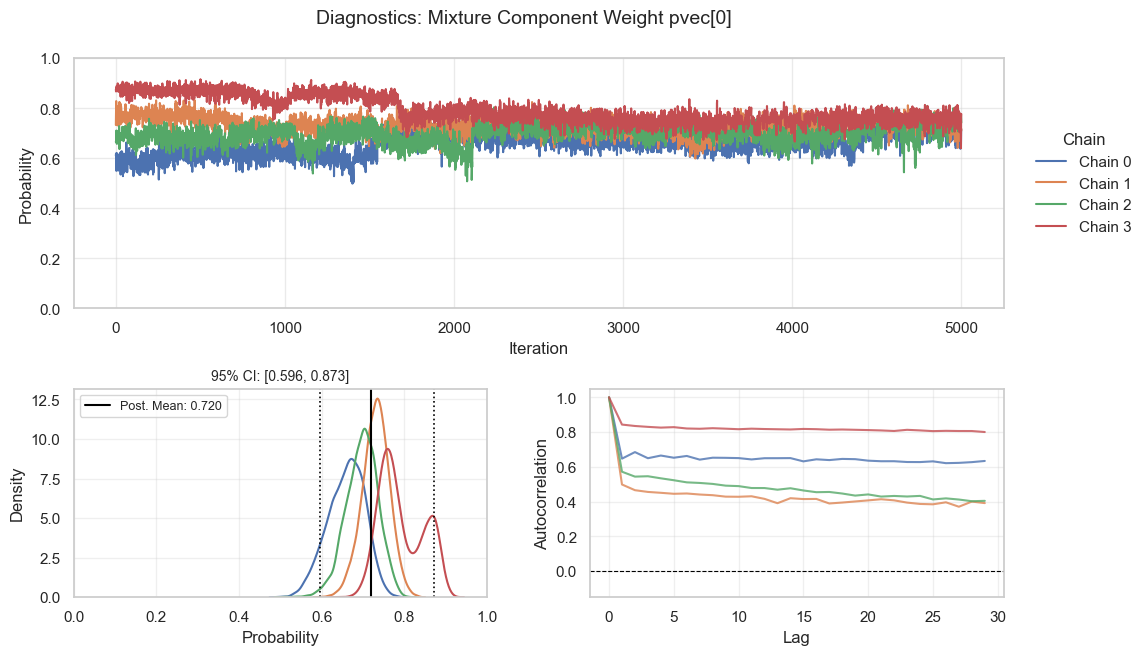

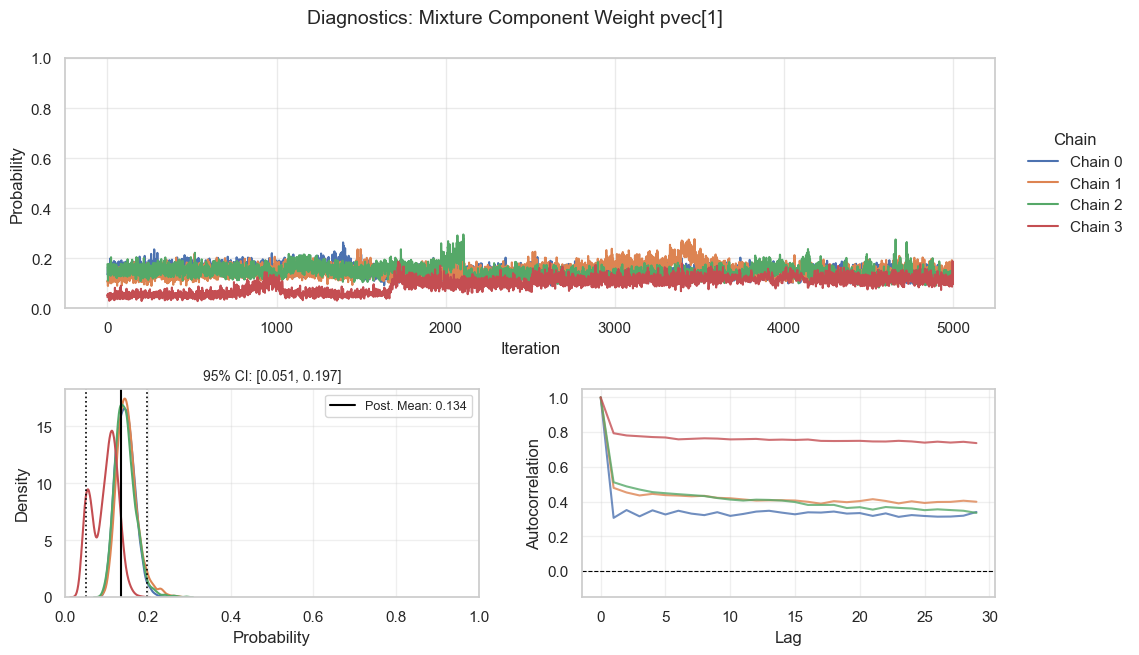

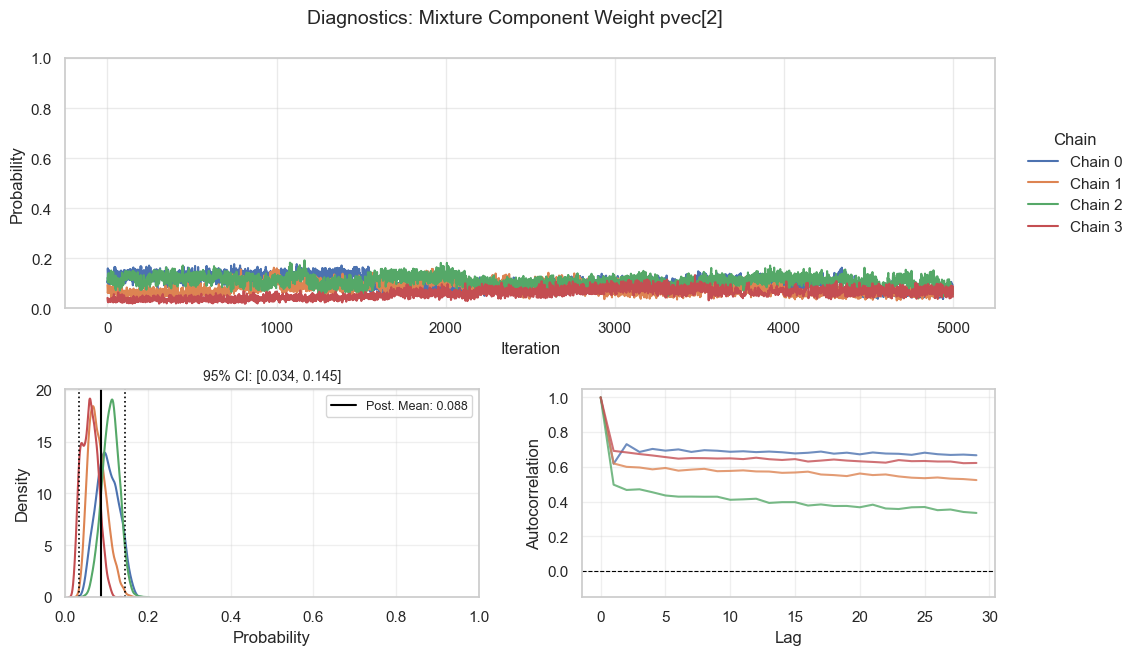

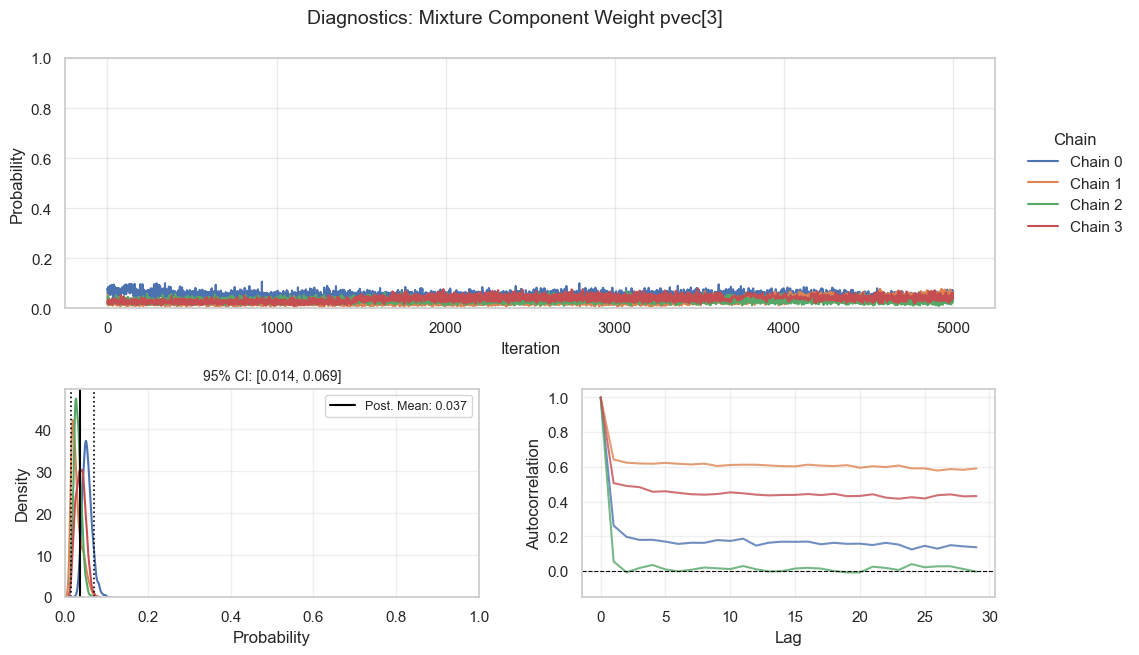

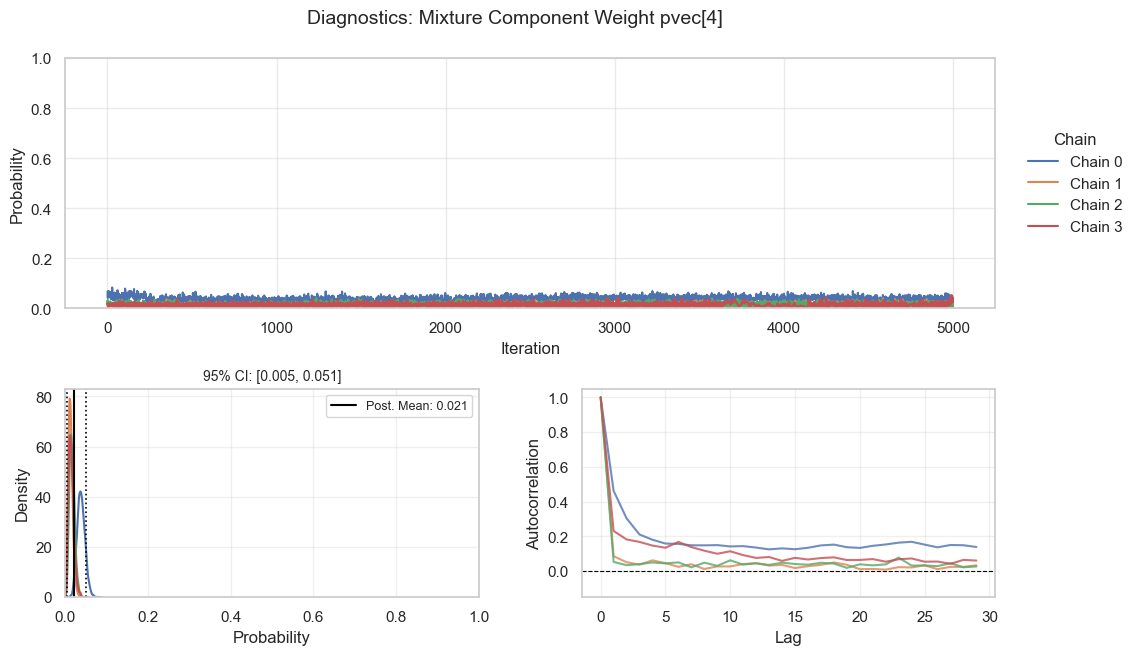

In [8]:
pvec_samples_raw# Pull the perfectly aligned simplex probabilities directly from our new dictionary
aligned_pvec = aligned_samples["pvec"]

flat_pvec = aligned_pvec.reshape(-1, K)
print("Posterior mean pvec (Aligned):", flat_pvec.mean(axis=0))

def plot_pvec_diagnostics(pvec_samples_array, K, n_lags=30):
    """Goose-style trace / density / ACF for each mixture weight."""
    n_chains, n_draws, _ = pvec_samples_array.shape

    for k in range(K):
        fig = plt.figure(figsize=(12, 7))
        fig.suptitle(f"Diagnostics: Mixture Component Weight pvec[{k}]", fontsize=14, y=0.95)
        gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.35, wspace=0.25)

        # 1. Trace Plot
        ax_trace = fig.add_subplot(gs_layout[0, :])
        for chain in range(n_chains):
            ax_trace.plot(pvec_samples_array[chain, :, k], label=f"Chain {chain}")
        ax_trace.set_xlabel("Iteration")
        ax_trace.set_ylabel("Probability")
        ax_trace.set_ylim(0, 1)
        ax_trace.grid(True, alpha=0.4)
        ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

        # 2. Density Plot
        ax_dens = fig.add_subplot(gs_layout[1, 0])
        all_draws = pvec_samples_array[:, :, k].reshape(-1)
        post_mean = all_draws.mean()
        ci_low, ci_high = np.percentile(all_draws, [2.5, 97.5])

        for chain in range(n_chains):
            sns.kdeplot(pvec_samples_array[chain, :, k], ax=ax_dens, fill=False)
        ax_dens.axvline(post_mean,    color="black", linestyle="-",  lw=1.5, label=f"Post. Mean: {post_mean:.3f}")
        ax_dens.axvline(ci_low,       color="black", linestyle=":",  lw=1.2)
        ax_dens.axvline(ci_high,      color="black", linestyle=":",  lw=1.2)
        
        ax_dens.set_xlabel("Probability")
        ax_dens.set_ylabel("Density")
        ax_dens.set_xlim(0, 1)
        ax_dens.legend(fontsize=9)
        ax_dens.grid(True, alpha=0.3)
        ax_dens.set_title(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]", fontsize=10)

        # 3. Autocorrelation Plot
        ax_acf = fig.add_subplot(gs_layout[1, 1])
        for chain in range(n_chains):
            ax_acf.plot(compute_acf(pvec_samples_array[chain, :, k], nlags=n_lags), alpha=0.8, label=f"Chain {chain}")
        ax_acf.axhline(0, color="black", lw=0.8, linestyle="--")
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylabel("Autocorrelation")
        ax_acf.set_ylim(-0.15, 1.05)
        ax_acf.grid(True, alpha=0.3)

        plt.show()

def pvec_summary_table(pvec_samples_array, K):
    """Generates a summary DataFrame for the mixture component weights."""
    flat = pvec_samples_array.reshape(-1, K)
    rows = []
    for k in range(K):
        draws = flat[:, k]
        ci_low, ci_high = np.percentile(draws, [2.5, 97.5])
        rows.append({
            "Component":      k,
            "Posterior_Mean": draws.mean(),
            "Posterior_Std":  draws.std(),
            "CI_2.5%":        ci_low,
            "CI_97.5%":       ci_high
        })
    return pd.DataFrame(rows).set_index("Component").round(4)


print("\n=== ALIGNED pvec: Posterior Summary ===")
# Pass aligned_pvec here!
display(pvec_summary_table(aligned_pvec, K))

print("\n=== ALIGNED pvec: Goose-Style Chain Diagnostics ===")
# Pass aligned_pvec here!
plot_pvec_diagnostics(aligned_pvec, K)